In [6]:
import os
import boto3
import s3fs

session = boto3.Session(
    profile_name="DatafactoryDeveloper-781690932061",
    region_name="eu-west-1"
)
s3_client = session.client("s3")

import knowledge_retrieval as rag 

rag.set_boto3_session(session)

x = rag.retrieve_context("What is retention")
print(len(x["sources"]))
 
out = rag.ask("What is retention")
print(out["answer"])



6
# What is Retention

**Retention** in papermaking refers to the ability to keep fine particles (fines, fillers, and other additives) in the paper sheet during the forming process, rather than losing them through the forming fabric into the white water system.

## Key Aspects of Retention:

### 1. **Basic Definition**
Retention is the process of capturing and holding solid materials—particularly fines (small fiber fragments) and fillers (like calcium carbonate, kaolin, talc)—within the fiber network as the paper sheet is formed [papermaking_science_technology.pdf:d6f6f20ccb65b658:1218:0].

### 2. **Why Retention Matters**

**Benefits of improved retention include:**
- Increased production capacity
- Better drainage and dewatering
- Reduced steam consumption
- Lower COD and BOD in effluent
- Higher filler levels in the sheet
- Better printability and opacity
- Less linting and dusting
- Reduced two-sidedness [chemicals_fundamentals.pdf:ab0dbcd601d60067:5:0]

### 3. **Retention Mechanis

In [2]:
print(session.client("sts").get_caller_identity())

{'UserId': 'AROA3MADJBNORKPXPCTFN:Miguel.Angel.Gonzalez@dssmith.com', 'Account': '781690932061', 'Arn': 'arn:aws:sts::781690932061:assumed-role/AWSReservedSSO_DatafactoryDeveloper_119239aa22a5c202/Miguel.Angel.Gonzalez@dssmith.com', 'ResponseMetadata': {'RequestId': '32ce5f6b-ed7b-4a6a-9cd7-dc8cc966a59c', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '32ce5f6b-ed7b-4a6a-9cd7-dc8cc966a59c', 'x-amz-sts-extended-request-id': 'MTpldS13ZXN0LTE6UzoxNzczNzQxMTM5ODY1OlI6SlhzNW5qczg=', 'content-type': 'text/xml', 'content-length': '525', 'date': 'Tue, 17 Mar 2026 09:52:19 GMT'}, 'RetryAttempts': 0}}


In [4]:
import os
import boto3
import s3fs

session = boto3.Session(
    #profile_name="DatafactoryAdministrator-636452271875",
    profile_name="DatafactoryDeveloper-781690932061",
    region_name="eu-west-1"
)
s3 = session.client("s3")


creds = session.get_credentials().get_frozen_credentials()

fs = s3fs.S3FileSystem(
    anon=False,
    key=creds.access_key,
    secret=creds.secret_key,
    token=creds.token,
    client_kwargs={"region_name": 'eu-west-1'}
)

In [5]:
import pandas as pd
import io
import importlib
import process_data_tools as pdt
 
importlib.reload(pdt)
pdt.set_filesystem(fs)

In [68]:
import importlib
import process_data_tools as pdt
 
importlib.reload(pdt)
 
df_all = pdt.load_turnup_data()
print(df_all.shape)
print(df_all.head())

(3289, 501)
           Wedge_Time  MBS_SCT_MD  MBS_SCT_CD   MBS_Burst  MBS_CMT30  \
0 2025-06-04 13:50:00        3.23        2.00  284.779999      153.0   
1 2025-06-04 14:44:00        3.41        2.01  280.779999      153.0   
2 2025-06-04 15:39:00        3.29        2.02  276.450012      153.0   
3 2025-06-04 16:38:00        3.29        2.02  276.450012      153.0   
4 2025-06-05 00:24:00        3.33        1.96  276.700012      153.0   

   MBS_Current_reel_ID AB_Grade_ID  Stock_pump_power        Speed  \
0             12503787     3200115        740.900024  1138.900024   
1             12503788     3200115        737.600037  1139.000000   
2             12503789     3200115        740.100037  1138.099976   
3             12503791     3200115        738.600037  1137.699951   
4             12503799     3300100        746.000000  1250.000000   

   Current_reel_weight  ...  Electricity_index  Electricity_sqm  SCT_CD_index  \
0         53111.402344  ...         318.335876         0.03

In [2]:
cols = pdt.get_available_columns()
print(len(cols))
print(cols[:30])

501
['Wedge_Time', 'MBS_SCT_MD', 'MBS_SCT_CD', 'MBS_Burst', 'MBS_CMT30', 'MBS_Current_reel_ID', 'AB_Grade_ID', 'Stock_pump_power', 'Speed', 'Current_reel_weight', 'Current_reel_width', 'Current_reel_length', 'Production_Rate__T/h_', 'Current_basis_weight', 'Current_reel_moisture_average(reel)', 'Actual_moisture', 'Current_reel_dry_average', 'BSW_2_sigma', 'Mois_Size_Press_2_sigma', 'Mois_2_sigma', 'Contact_pressure_reel_holders', 'Reel_discharge_pressure', 'Draw_meaurement_pope_reel_FS', 'Draw_measurement_pope_reel_DS', 'Total_draw_measurement_pope_reel', 'Contact_pressure_secondary_arm_OS', 'Contact_pressure_secondary_arm_DS', 'Retentionsmittel_Menge_l/h__0..9000_l/h__', 'Bentonitmenge_z._Mischrohr__-10..9000_l/h_', 'Bentonitmenge_z._Siebwasserturm__-10..9000_l/h_']


In [14]:
import pandas as pd

In [15]:
mask = pd.Series(True, index=df_all.index)

In [24]:
df_small = pdt.get_wide_process_data(
    start="2025-10-01",
    end="2025-10-10",
    grade='6010120',
    columns=["MBS_Current_reel_ID", "Wedge_Time", "AB_Grade_ID"]
)
 
print(df_small.head())
print(df_small.shape)

      MBS_Current_reel_ID          Wedge_Time AB_Grade_ID
1403             12506543 2025-10-01 12:19:00     6010120
1404             12506545 2025-10-01 14:12:00     6010120
1405             12506546 2025-10-01 14:18:00     6010120
1406             12506547 2025-10-01 15:24:00     6010120
1407             12506549 2025-10-01 16:39:00     6010120
(53, 3)


In [25]:
fx = pdt.get_feature_snapshot(
    grade="6010120"
)
 
print(fx.shape)
print(fx.head())

(980, 501)
            Wedge_Time  MBS_SCT_MD  MBS_SCT_CD   MBS_Burst   MBS_CMT30  \
80 2025-06-09 14:05:00        3.55        2.16  273.869995  193.159073   
81 2025-06-09 15:03:00        3.85        2.31  281.910004  193.159073   
82 2025-06-09 15:50:00        3.68        2.24  287.519989  197.000000   
83 2025-06-09 16:38:00        3.68        2.24  287.519989  197.000000   
84 2025-06-10 00:09:00        3.66        2.18  275.779999  187.000000   

    MBS_Current_reel_ID AB_Grade_ID  Stock_pump_power        Speed  \
80             12503923     6010120        833.000000  1230.650024   
81             12503924     6010120        856.299988  1230.150024   
82             12503925     6010120        852.299988  1230.199951   
83             12503926     6010120        851.900024  1230.400024   
84             12503936     6010120        852.299988  1229.849976   

    Current_reel_weight  ...  Electricity_index  Electricity_sqm  \
80         18063.437500  ...         289.860168        

In [8]:
import assistant_router as ar

In [29]:
out = ar.answer("What is retention in papermaking?")
print(out["answer"])

# What is Retention in Papermaking?

Retention in papermaking refers to **the ability to keep fibers, fines (small fiber fragments), and fillers (mineral pigments) in the paper sheet during the manufacturing process**, rather than losing them through the wire mesh as the water drains away.

## Two Types of Retention Mechanisms

### 1. **Mechanical Retention (Filtration)**
This is the physical trapping of particles as water drains through the forming fiber mat. Mechanical retention is:
- Size-dependent, with retention increasing as particle size increases
- Very low for single pigment particles before a fibrous mat forms
- Enhanced after web formation through entrapment in fiber lumen or between fibrils [papermaking_science_technology.pdf:d6f6f20ccb65b658:1217:0]

### 2. **Chemical Retention (Adsorption)**
This involves using chemical additives (retention polymers) to attach particles to fiber surfaces through co-flocculation before web build-up [papermaking_science_technology.pdf:d6f6f

In [9]:
out = ar.answer("Show electricity data")
print(out["message"])

Loaded 7238 rows from dataset.


In [2]:
import importlib
import prediction_tools as pt
 
importlib.reload(pt)
print(pt.list_available_components())

['fibre', 'steam', 'electricity', 'starch']


In [3]:
import process_data_tools as pdt
 
df_all = pdt.load_turnup_data()
row = df_all.iloc[0]

In [5]:
print("steam:", len(pt.get_required_features("steam")))
print("electricity:", len(pt.get_required_features("electricity")))
print("starch:", len(pt.get_required_features("starch")))
print("fibre:", pt.get_required_features("fibre"))

steam: 24
electricity: 24
starch: 12
fibre: ['Current_basis_weight', 'Starch_uptake__g/m2_', 'Current_reel_moisture_average(reel)']


In [6]:
print("fibre:", pt.predict_component_from_row(row, "fibre"))
print("steam:", pt.predict_component_from_row(row, "steam"))
print("electricity:", pt.predict_component_from_row(row, "electricity"))
print("starch:", pt.predict_component_from_row(row, "starch"))

fibre: 127.01268768310547
steam: -985.1257303052079
electricity: 207.9926614504653
starch: 5.307907057754705


In [3]:
import importlib
import shap_tools as st
 
importlib.reload(st)
print(st.list_shap_components())

['steam', 'electricity', 'starch']


In [4]:
res = st.explain_grade_component(
    component="electricity",
    grade_id="6010120"
)
 
print(type(res))
print(res["component"])
print(res["grade_id"])
print(res["Xe"].shape)
print(len(res["feature_names"]))
print(res["shap_values"].shape)

PermutationExplainer explainer: 201it [02:48,  1.19it/s]                         

<class 'dict'>
electricity
6010120
(200, 24)
24
(200, 24)


In [5]:
fig = st.build_shap_beeswarm_figure(res, max_features=15)
fig.show()

In [27]:
import importlib
import assistant_router as ar
 
importlib.reload(ar)

<module 'assistant_router' from 'c:\\workspace\\costimiser\\assistant_router.py'>

In [130]:
import importlib
import aws_context as awsc
import knowledge_retrieval as kr
 
session = boto3.Session(
    profile_name="DatafactoryDeveloper-781690932061",
    region_name="eu-west-1",
)
 
awsc.set_session(session)
 
importlib.reload(kr)
kr.set_boto3_session(session)
 
out = kr.ask("What is retention in papermaking?")
print(out["answer"])

# What is Retention in Papermaking?

Retention in papermaking refers to **the ability to keep fibers, fines (small fiber fragments), and fillers (mineral pigments) in the paper sheet during the manufacturing process**, rather than losing them through drainage water as the paper web is formed.

## Two Types of Retention Mechanisms

### 1. **Mechanical Retention (Filtration)**
This is the physical trapping of particles as water drains through the forming fiber mat. Mechanical retention is:
- Size-dependent, with retention increasing as particle size increases
- Very low for single pigment particles before a fibrous mat forms
- Enhanced when fine pigments are trapped within fiber lumen or between fibrils on the fiber surface [papermaking_science_technology.pdf:d6f6f20ccb65b658:1217:0]

### 2. **Chemical Retention (Adsorption)**
This involves using chemical additives (retention polymers) to attach particles to fiber surfaces through co-flocculation before web build-up [papermaking_science_

In [29]:
import boto3
import importlib
import aws_context as awsc
import knowledge_retrieval as kr
import process_data_tools as pdt
import prediction_tools as pt
import shap_tools as st
import assistant_router as ar
import cost_driver_tools as cdt
 
session = boto3.Session(
    profile_name="DatafactoryDeveloper-781690932061",
    region_name="eu-west-1",
)
 
awsc.set_session(session)
 
importlib.reload(kr)
kr.set_boto3_session(session)
 
importlib.reload(pdt)
importlib.reload(pt)
importlib.reload(st)
importlib.reload(ar)
importlib.reload(cdt)

c:\workspace\costimiser\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

c:\workspace\costimiser\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator Ridge from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

c:\workspace\costimiser\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator Pipeline from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use

<module 'cost_driver_tools' from 'c:\\workspace\\costimiser\\cost_driver_tools.py'>

In [2]:
out = ar.answer("What is retention in papermaking?")
print(out["type"])
print(out["answer"])

knowledge
# What is Retention in Papermaking?

Retention in papermaking refers to **the ability to keep solid materials (fibers, fines, and fillers) in the paper sheet during the manufacturing process**, rather than losing them through drainage water as the paper web is formed.

## Key Aspects of Retention:

### 1. **Two Types of Retention Mechanisms**

**Mechanical Retention (Filtration):**
- Occurs after formation of a fibrous mat where filtration takes place
- Size-dependent mechanism - retention increases with increasing particle size
- Very fine pigment can be trapped within fiber lumen or between fibrils on the fiber surface
- Coarse particles are poorly retained initially [papermaking_science_technology.pdf:d6f6f20ccb65b658:1216:1]

**Chemical Retention (Adsorption):**
- Involves special chemical additives that cause particles to attach to fiber surfaces through co-flocculation before web build-up
- Results in more homogeneous sheet structure with better product economy
- Polyme

In [19]:
out = ar.answer_shap(
    component="electricity",
    grade_id="6010120"
)
 
print(out["type"])
print(out["component"])
print(out["grade_id"])
print(out["Xe_shape"])

shap
electricity
6010120
(200, 24)


In [8]:
df = cdt.run_cost_driver_analysis(
    target_range=(target_range[0].strftime("%F"), target_range[1].strftime("%F")),
    baseline_range=(baseline_range[0].strftime("%F"), baseline_range[1].strftime("%F")),
    cost_component="electricity",
    grade="6010120"
)
 
print(df.head())

['historic' 'current']
['historic' 'current']
  AB_Grade_ID                                variable  contribution  \
0     6010120                               retention      7.199182   
1     6010120                    Vacuum_suction_box_9     -0.004741   
2     6010120                            Draw_PD4-PD5     -0.000016   
3     6010120  Vacuum_presszone_of_suction-press_roll      0.086551   
4     6010120                                   Speed     -1.257426   

   value_change  
0     -0.058920  
1      0.000060  
2     -0.000111  
3     -0.007861  
4    135.002686  


In [11]:
import importlib
import assistant_router as ar
 
importlib.reload(ar)

<module 'assistant_router' from 'c:\\workspace\\costimiser\\assistant_router.py'>

In [12]:
out = ar.answer_cost_driver_analysis(
    target_range=(target_range[0].strftime("%F"), target_range[1].strftime("%F")),
    baseline_range=(baseline_range[0].strftime("%F"), baseline_range[1].strftime("%F")),
    cost_component="electricity",
    grade="6010120"
)
 
print(out["type"])
print(out["component"])
print(out["n_rows"])
print(out["summary"]["top_increase"])
print(out["summary"]["top_decrease"])

['historic' 'current']
['historic' 'current']
cost_driver_analysis
electricity
24
[{'AB_Grade_ID': '6010120', 'variable': 'retention', 'contribution': 7.199182373988985, 'value_change': -0.058920085430145264}, {'AB_Grade_ID': '6010120', 'variable': 'Lip_settings', 'contribution': 0.47086823672230277, 'value_change': -0.22878170013427734}, {'AB_Grade_ID': '6010120', 'variable': 'Vacuum_wire_suction_box_2', 'contribution': 0.29627876250968593, 'value_change': -0.062469482421875}, {'AB_Grade_ID': '6010120', 'variable': 'White_water_temperature', 'contribution': 0.10862080205838931, 'value_change': 2.075550079345703}, {'AB_Grade_ID': '6010120', 'variable': 'Vacuum_presszone_of_suction-press_roll', 'contribution': 0.0865511824498303, 'value_change': -0.007861435413360596}]
[{'AB_Grade_ID': '6010120', 'variable': 'Consistency_white_water', 'contribution': -7.63267031502063, 'value_change': 0.8561058044433594}, {'AB_Grade_ID': '6010120', 'variable': 'Speed', 'contribution': -1.257425642072998

In [15]:
out = ar.answer_cost_driver_analysis(
    target_range=(target_range[0].strftime("%F"), target_range[1].strftime("%F")),
    baseline_range=(baseline_range[0].strftime("%F"), baseline_range[1].strftime("%F")),
    cost_component="electricity",
    grade="6010120",
    lang="en"
)
 
print(out["narrative"])

['historic' 'current']
['historic' 'current']
For grade 6010120, the cost change is mainly explained by the following factors (top 20% by contribution):
Cost-reducing drivers:
- Consistency white water increased (+0.86)
- Speed increased (+135.00)
- Vacuum wire suction box 1 decreased (-0.03)
Cost-increasing drivers:
- Retention decreased (-0.06)
- Lip settings decreased (-0.23)


In [16]:
import query_parser as qp
 
print(qp.parse_query("Explain electricity cost drivers for grade 6010120"))
print(qp.parse_query("Show SHAP for starch in 6010120"))
print(qp.parse_query("Predict fibre cost for grade 6010120"))

{'intent': 'cost_driver', 'cost_component': 'electricity', 'grade': '6010120', 'raw_query': 'Explain electricity cost drivers for grade 6010120'}
{'intent': 'shap', 'cost_component': 'starch', 'grade': '6010120', 'raw_query': 'Show SHAP for starch in 6010120'}
{'intent': 'prediction', 'cost_component': 'fibre', 'grade': '6010120', 'raw_query': 'Predict fibre cost for grade 6010120'}


In [17]:
import importlib
import assistant_router as ar
 
importlib.reload(ar)

<module 'assistant_router' from 'c:\\workspace\\costimiser\\assistant_router.py'>

In [18]:
out = ar.answer("Show SHAP for electricity in grade 6010120")
print(out["type"])
print(out["component"])
print(out["grade_id"])

PermutationExplainer explainer: 201it [00:13,  8.30it/s]                         


shap
electricity
6010120


In [21]:
out['figure']

In [22]:
out = ar.answer("Predict fibre cost for grade 6010120")
print(out)

{'type': 'prediction', 'component': 'fibre', 'grade': '6010120', 'prediction': 128.03720092773438}


In [32]:
out = ar.answer("Explain electricity cost drivers for grade 6010120 for week 13")
print(out["target_range"])
print(out["baseline_range"])
print(out["narrative"])

['historic']


KeyError: 'variable'

In [31]:
print(out)

{'type': 'cost_driver_analysis', 'component': 'electricity', 'grade': '6010120', 'target_range': (datetime.date(2026, 3, 9), datetime.date(2026, 3, 14)), 'baseline_range': (datetime.date(2026, 2, 8), datetime.date(2026, 3, 8)), 'used_default_ranges': True, 'n_rows': 24, 'raw':    AB_Grade_ID                                variable  contribution  \
0      6010120                               retention      7.199182   
1      6010120                    Vacuum_suction_box_9     -0.004741   
2      6010120                            Draw_PD4-PD5     -0.000016   
3      6010120  Vacuum_presszone_of_suction-press_roll      0.086551   
4      6010120                                   Speed     -1.257426   
5      6010120                 Vacuum_uhle-box_Pick-Up     -0.020846   
6      6010120               Vacuum_wire_suction_box_1     -0.374718   
7      6010120             Vacuum_uhle-box_bottom_felt      0.048268   
8      6010120                 Consistency_white_water     -7.632670   
9 

In [24]:
import importlib
import query_parser as qp
 
importlib.reload(qp)
 
print(qp.parse_query(
    "Explain electricity cost drivers for grade 6010120 between 2025-01-10 and 2025-01-20 compared with 2024-12-10 and 2024-12-20"
))

{'intent': 'cost_driver', 'cost_component': 'electricity', 'grade': '6010120', 'target_range': ('2025-01-10', '2025-01-20'), 'baseline_range': ('2024-12-10', '2024-12-20'), 'raw_query': 'Explain electricity cost drivers for grade 6010120 between 2025-01-10 and 2025-01-20 compared with 2024-12-10 and 2024-12-20'}


In [25]:
import time_context as tc
 
x = tc.get_default_interval_ranges()
print(x)
 
msg = tc.build_default_ranges_message(
    target_range=x["target_range"],
    baseline_range=x["baseline_range"],
    used_any_default=True,
    lang="en",
)
print(msg)

{'target_range': (datetime.date(2026, 3, 9), datetime.date(2026, 3, 14)), 'baseline_range': (datetime.date(2026, 2, 8), datetime.date(2026, 3, 8)), 'min_date': Timestamp('2025-06-04 13:50:00'), 'max_date': Timestamp('2026-03-16 06:51:00')}
No time intervals were specified, so the default periods were used: target=2026-03-09 to 2026-03-14, baseline=2026-02-08 to 2026-03-08.


In [34]:
import importlib
import query_parser as qp
 
importlib.reload(qp)
 
print(qp.parse_query("Explain electricity cost drivers for grade 6010120 for week 13"))
print(qp.parse_query("Explain electricity cost drivers for grade 6010120 for day 2026-03-18"))
print(qp.parse_query("Explain electricity cost drivers for grade 6010120 for month February"))

{'intent': 'cost_driver', 'cost_component': 'electricity', 'grade': '6010120', 'target_range': (datetime.date(2026, 3, 23), datetime.date(2026, 3, 28)), 'baseline_range': (datetime.date(2026, 2, 23), datetime.date(2026, 3, 23)), 'raw_query': 'Explain electricity cost drivers for grade 6010120 for week 13'}
{'intent': 'cost_driver', 'cost_component': 'electricity', 'grade': '6010120', 'target_range': (datetime.date(2026, 3, 18), datetime.date(2026, 3, 19)), 'baseline_range': (datetime.date(2026, 2, 18), datetime.date(2026, 3, 18)), 'raw_query': 'Explain electricity cost drivers for grade 6010120 for day 2026-03-18'}
{'intent': 'cost_driver', 'cost_component': 'electricity', 'grade': '6010120', 'target_range': (datetime.date(2026, 2, 1), datetime.date(2026, 3, 1)), 'baseline_range': (datetime.date(2026, 1, 1), datetime.date(2026, 2, 1)), 'raw_query': 'Explain electricity cost drivers for grade 6010120 for month February'}


In [36]:
out = ar.answer("Explain electricity cost drivers for grade 6010120 for week 11")
print(out["target_range"])
print(out["baseline_range"])
print(out["narrative"])

['historic' 'current']
['historic' 'current']
(datetime.date(2026, 3, 9), datetime.date(2026, 3, 14))
(datetime.date(2026, 2, 9), datetime.date(2026, 3, 9))
For grade 6010120, the cost change is mainly explained by the following factors (top 20% by contribution):
Cost-reducing drivers:
- Consistency white water increased (+0.82)
- Speed increased (+135.19)
- Vacuum wire suction box 1 decreased (-0.03)
Cost-increasing drivers:
- Retention decreased (-0.06)
- Lip settings decreased (-0.23)


In [40]:
import importlib
import time_context as tc
import assistant_router as ar
 
importlib.reload(tc)
importlib.reload(ar)

<module 'assistant_router' from 'c:\\workspace\\costimiser\\assistant_router.py'>

In [43]:
out = ar.answer("Predict electricity cost for grade 6010120  for week 14")
 
print(out["target_range"])
print(out["prediction"])
print(out["message"])

(datetime.date(2026, 3, 30), datetime.date(2026, 4, 4))
291.50150341385165



In [44]:
import importlib
import process_data_tools as pdt
import assistant_router as ar
 
importlib.reload(pdt)
importlib.reload(ar)

<module 'assistant_router' from 'c:\\workspace\\costimiser\\assistant_router.py'>

In [51]:
out = ar.answer("Show SHAP for electricity in grade 6010120 between 2026-03-16 and 2026-03-21 compared with 2026-02-16 and 2026-03-16")
print(out["target_range"])
print(out["baseline_range"])
print(out["used_default_ranges"])
print(out["message"])
print(out["Xe_shape"])

('2026-03-16', '2026-03-21')
('2026-02-16', '2026-03-16')
False

(9, 24)


In [58]:
import importlib
import query_parser as qp
import time_context as tc
import assistant_router as ar
 
importlib.reload(qp)
importlib.reload(tc)
importlib.reload(ar)

<module 'assistant_router' from 'c:\\workspace\\costimiser\\assistant_router.py'>

In [72]:
out = ar.answer("Show data for grade 6010120 from 2026-03-01 to 2026-03-10")
print(out["target_range"])
print(out["n_rows"])

('2026-03-01', '2026-03-10')
51


In [73]:
out

{'type': 'process_data',
 'grade': '6010120',
 'target_range': ('2026-03-01', '2026-03-10'),
 'used_default_range': False,
 'n_rows': 51,
 'data':               Wedge_Time  MBS_SCT_MD  MBS_SCT_CD   MBS_Burst   MBS_CMT30  \
 3070 2026-03-01 15:02:00        4.02        2.12  284.429993  193.159073   
 3071 2026-03-01 15:41:00        4.24        2.10  299.739990  194.000000   
 3072 2026-03-01 16:38:00        4.24        2.10  299.739990  194.000000   
 3073 2026-03-02 00:43:00        4.07        2.11  295.769989  196.000000   
 3074 2026-03-02 01:30:00        4.05        2.11  296.679993  196.000000   
 3075 2026-03-02 02:18:00        3.86        1.98  283.049988  199.000000   
 3076 2026-03-02 03:06:00        4.22        2.15  299.820007  199.000000   
 3077 2026-03-02 03:54:00        4.09        2.15  296.549988  199.000000   
 3078 2026-03-02 04:42:00        4.13        2.15  300.320007  199.000000   
 3079 2026-03-02 05:29:00        4.28        2.23  308.260010  199.000000   
 3080 2

In [63]:
import importlib
import time_context as tc
import assistant_router as ar
 
importlib.reload(tc)
importlib.reload(ar)

<module 'assistant_router' from 'c:\\workspace\\costimiser\\assistant_router.py'>

In [64]:
out = ar.answer("Predict electricity for grade 6010120")
print(out["target_range"])
print(out["used_default_range"])
print(out["used_proxy_latest"])
print(out["prediction"])
print(out["message"])

(datetime.date(2026, 3, 23), datetime.date(2026, 3, 28))
True
True
291.50150341385165
No time interval was specified, so the next week was used by default: 2026-03-23 to 2026-03-28.

Because no observed process data is available for that interval, the prediction uses the latest available operating state for this grade as a proxy.


In [65]:
out = ar.answer("Predict fibre for grade 6010120 from 2026-03-01 to 2026-03-10")
print(out["target_range"])
print(out["used_proxy_latest"])
print(out["prediction"])
print(out["message"])

('2026-03-01', '2026-03-10')
False
127.40198323757785
The prediction is based on a representative operating state from the selected interval.


In [93]:
[v for v in df_all.columns if "starch" in v.lower()]

['Starch_uptake_by_paper_Top_Roll__g/m2_',
 'Starch_uptake_by_paper_Bottom_Roll__g/m2_',
 'Pressure_of_Starch_flow_Speedsizer_Bottom_Roll~^0',
 'Starch_consumption_Bottom___m³/h_',
 'Starch_consumption_Top__m³/h_',
 'Consistency_starch_main_line',
 'Pressure_of_Starch_flow_Speedsizer_Top_Roll',
 'Flow_starch_main_line_to_working_tank_2~^0',
 'Flow_starch_main_line_to_working_tank_1~^0',
 'Starch_Top_Roll__ml/m²_',
 'Starch_Bottom_Roll__ml/m²_',
 'Steam_flow_to_starch_kitchen',
 'Starch_flow_to_inactivation',
 'Pressure_starch_main_line',
 'Temperature_starch_working_tank_1',
 'Temperature_starch_working_tank_2',
 'Starch_application_FW_in_ml',
 'Starch_application_BW_in_ml',
 'Starch_mass_flow__kg/T_',
 'Starch__€/T_',
 'Starch_uptake__g/m2_',
 'ratio_starch',
 'Starch_current__€/h_',
 'Flow_starch_main_line_to_working_tank',
 'concentration_starch_working_tank_1',
 'concentration_starch_working_tank_2']

In [92]:
import importlib
import process_data_tools as pdt
import scenario_tools as st
 
importlib.reload(pdt)
importlib.reload(st)
 
# 1. Load full turnup dataset
df_all = pdt.load_turnup_data()
 
# 2. (Optional but recommended) filter before scenario
df = df_all[df_all["AB_Grade_ID"] == "6010120"]
 
# 3. Select reference turnup
ref = st.get_reference_turnup(
    df,
    grade="6010120"
)
 
# 4. Inspect result
print(st.describe_reference_turnup(ref))
print(ref["row"][["MBS_Current_reel_ID", "AB_Grade_ID", "Wedge_Time"]])

Selection mode: grade_latest
Matched reel: 12601970
Matched grade: 6010120
Matched time: 2026-03-16 06:51:00
Requested grade: 6010120
  MBS_Current_reel_ID AB_Grade_ID           Wedge_Time
0            12601970     6010120  2026-03-16 06:51:00


In [96]:
import importlib
import process_data_tools as pdt
import scenario_tools as st
 
importlib.reload(pdt)
importlib.reload(st)
 
# 1. Load data
df_all = pdt.load_turnup_data()
 
# 2. Get reference turnup
ref = st.get_reference_turnup(
    df_all,
    grade="6010120",
    schema={
        "reel_id": "MBS_Current_reel_ID",
        "grade": "AB_Grade_ID",
        "time": "Wedge_Time",
    }
)
 
# 3. Apply intervention
mod = st.apply_interventions(
    ref["row"],
    interventions=[
        {
            "variable": "Starch_uptake__g/m2_",
            "mode": "relative",   # try also "delta" or "absolute"
            "value": -0.10        # reduce by 10%
        }
    ]
)
 
# 4. Compare
var = "Starch_uptake__g/m2_"
 
print("REFERENCE VALUE:")
print(ref["row"][var].values[0])
 
print("\nMODIFIED VALUE:")
print(mod["row"][var].values[0])
 
print("\nAPPLIED INTERVENTIONS:")
print(mod["applied_interventions"])
 
print("\nWARNINGS:")
print(mod["warnings"])

REFERENCE VALUE:
5.784336

MODIFIED VALUE:
5.205902481079102

APPLIED INTERVENTIONS:
[{'variable': 'Starch_uptake__g/m2_', 'mode': 'relative', 'value': -0.1, 'old_value': 5.784336090087891, 'new_value': 5.205902481079102}]

WARNINGS:
[]


In [106]:
import importlib
import scenario_tools as st
 
importlib.reload(st)
 
sim = st.simulate_turnup_scenario(
    cost_component="steam",
    grade="6010120",
    interventions=[
        {
            "variable": 'Moisture_out_of_PreDryer',
            "mode": "absolute",
            "value": 7.28,
        }
    ],
)
 
print(st.describe_scenario_result(sim, decimals=10))

Cost component: steam
Baseline prediction: 886.4490742108
Scenario prediction: 875.5287324887
Delta prediction: -10.9203417221
Reference mode: grade_latest
Matched reel: 12601970
Matched grade: 6010120
Matched time: 2026-03-16 06:51:00
Intervention - Moisture_out_of_PreDryer: 9.1100425720 -> 7.2800000000 (mode=absolute, value=7.28)


In [119]:
import importlib
import assistant_router as ar
import query_parser as qp
import scenario_tools as st
 
importlib.reload(qp)
importlib.reload(st)
importlib.reload(ar)
 
q = "simulate electricity cost for grade 6010120 if Speed is increased by 10%"
 
parsed = qp.parse_query(q)
print(parsed)
 
out = ar.answer_scenario(
    cost_component=parsed.get("cost_component"),
    grade=parsed.get("grade"),
    reel_id=parsed.get("reel_id"),
    timestamp=parsed.get("timestamp"),
    target_range=parsed.get("target_range"),
    interventions=parsed.get("interventions"),
)
 
print(out["text"])

{'intent': 'simulate_scenario', 'cost_component': 'electricity', 'grade': '6010120', 'reel_id': None, 'timestamp': None, 'target_range': None, 'baseline_range': None, 'interventions': [{'variable': 'Speed', 'mode': 'delta', 'value': 10.0}], 'raw_query': 'simulate electricity cost for grade 6010120 if Speed is increased by 10%'}
Cost component: electricity
Baseline prediction: 291.5015
Scenario prediction: 290.4741
Delta prediction: -1.0274
Reference mode: grade_latest
Matched reel: 12601970
Matched grade: 6010120
Matched time: 2026-03-16 06:51:00
Intervention - Speed: 1253.9000 -> 1263.9000 (mode=delta, value=10.0)


In [109]:
out = ar.answer("simulate steam cost for grade 6010120 if Moisture_out_of_PreDryer is reduced by 10%")
print(out["text"] if isinstance(out, dict) and "text" in out else out)

Cost component: steam
Baseline prediction: 886.4491
Scenario prediction: 826.7765
Delta prediction: -59.6726
Reference mode: grade_latest
Matched reel: 12601970
Matched grade: 6010120
Matched time: 2026-03-16 06:51:00
Intervention - Moisture_out_of_PreDryer: 9.1100 -> -0.8900 (mode=delta, value=-10.0)


In [122]:
from datetime import date
import diagnosis_tools as diag

importlib.reload(diag)

<module 'diagnosis_tools' from 'c:\\workspace\\costimiser\\diagnosis_tools.py'>

In [125]:
from datetime import date
import diagnosis_tools as diag

importlib.reload(diag)
 

out = diag.run_diagnosis(
    target_range=(date(2026, 3, 1), date(2026, 3, 10)),
    baseline_range=(date(2026, 2, 1), date(2026, 3, 1)),
    objects="cost",
    levels=[1, 2, 3],
    grades=[6010120, 6010100],
)

print(out["combined_text"])
 
for block in out["blocks"]:
    print(block["level"], block["object_drilldown"])
    block["figure"].show()

For all considered grades, TOTAL cost saw a decrease of 1.65 €/t, resulting in 278.36 €/t.

Breaking down the overall cost change, 0.85 €/t was driven by a cheaper mix of grades, and 0.79 €/t was due to an improvement in the process.

For grade 6010100, TOTAL cost saw a decrease of 2.24 €/t, resulting in 284.21 €/t.

For grade 6010120, TOTAL cost saw a decrease of 0.46 €/t, resulting in 277.02 €/t.

Looking across individual grades, the strongest cost decrease was observed for grade 6010100 (-2.24 €/t). These movements stand out and may require further investigation.

Average change by component:

- **Steam__€/T_** decreased on average (-1.60 €/t).

- **Starch__€/T_** increased on average (+1.00 €/t).

- **Chemicals__€/T_** decreased on average (-0.35 €/t).

- **Fibre_cost__€/T_** decreased on average (-0.31 €/t).

- **Electricity__€/T_** decreased on average (-0.10 €/t).

A more detailed breakdown by component shows that the largest average increase comes from **Starch__€/T_** (+1.00 

2 cost


3 cost


In [126]:
import importlib
import query_parser as qp
import assistant_router as ar
 
importlib.reload(qp)
importlib.reload(ar)
 
q = "diagnose cost overall for grade 6010120 in March 2026"
parsed = qp.parse_query(q)
print(parsed)
 
out = ar.answer_diagnosis(
    target_range=parsed.get("target_range"),
    baseline_range=parsed.get("baseline_range"),
    grades=parsed.get("grades"),
    levels=parsed.get("levels"),
    objects=parsed.get("objects"),
    lang="en",
)
 
print(out["text"])

{'intent': 'diagnosis', 'cost_component': None, 'grade': '6010120', 'reel_id': None, 'timestamp': None, 'target_range': (datetime.date(2026, 3, 1), datetime.date(2026, 4, 1)), 'baseline_range': (datetime.date(2026, 2, 1), datetime.date(2026, 3, 1)), 'interventions': [], 'raw_query': 'diagnose cost overall for grade 6010120 in March 2026', 'levels': [1], 'objects': ['cost']}
For all considered grades, TOTAL cost saw a decrease of 1.04 €/t, resulting in 279.62 €/t.

Breaking down the overall cost change, 0.41 €/t was driven by a cheaper mix of grades, and 0.63 €/t was due to an improvement in the process.


In [129]:
import importlib
import query_parser as qp
import assistant_router as ar
 
importlib.reload(qp)
importlib.reload(ar)
 
out = ar.answer("diagnose cost by grade for grade 6010120 in March 2026")
print(out["text"])

For grade 3200115, TOTAL cost saw an increase of 1.33 €/t, resulting in 277.14 €/t.

For grade 6010085, TOTAL cost saw an increase of 1.77 €/t, resulting in 291.42 €/t.

For grade 6010100, TOTAL cost saw a decrease of 2.86 €/t, resulting in 283.59 €/t.

For grade 6010120, TOTAL cost saw a decrease of 1.47 €/t, resulting in 276.00 €/t.

Looking across individual grades, the strongest cost increase was observed for grade 6010085 (+1.77 €/t) and the strongest cost decrease was observed for grade 6010100 (-2.86 €/t). These movements stand out and may require further investigation.


In [ ]:
import importlib
import assistant_router as ar
from datetime import date
 
importlib.reload(ar)
 
out = ar.answer_diagnosis_with_scenario(
    target_range=(date(2026, 3, 1), date(2026, 3, 10)),
    baseline_range=(date(2026, 2, 1), date(2026, 3, 1)),
    grades=["6010120"],
    levels=[1],
    objects=["cost"],
    lang="en",
    cost_component="starch",
    interventions=[
        {
            "variable": "Starch_uptake__g/m2_",
            "mode": "relative",
            "value": -0.10,
        }
    ],
)
 
print(out["text"])

In [132]:
import importlib
import query_parser as qp
import analysis_planner as ap
 
importlib.reload(qp)
importlib.reload(ap)
 
q = "diagnose cost overall for grade 6010120 in March 2026"
parsed = qp.parse_query(q)
 
out = ap.make_plan(parsed, raw_query=q)
 
print(out["planning_context"]["allowed_tools"])
print(out["plan"])

['diagnosis', 'cost_driver', 'shap']
{'goal': 'diagnose', 'steps': [{'tool': 'diagnosis', 'purpose': 'Diagnose the issue across the requested drilldown levels and objects.', 'args': {'target_range': (datetime.date(2026, 3, 1), datetime.date(2026, 4, 1)), 'baseline_range': (datetime.date(2026, 2, 1), datetime.date(2026, 3, 1)), 'grades': ['6010120'], 'levels': [1], 'objects': ['cost'], 'lang': 'en'}}], 'final_template': 'diagnosis_only'}


In [133]:
import importlib

import query_parser as qp

import analysis_planner as ap

import analysis_executor as ae
 
importlib.reload(qp)

importlib.reload(ap)

importlib.reload(ae)
 
q = "diagnose cost overall for grade 6010120 in March 2026"
 
parsed = qp.parse_query(q)

plan_bundle = ap.make_plan(parsed, raw_query=q)

execution_out = ae.execute_plan(plan_bundle)
 
print(execution_out["plan"])

print("----")

for step in execution_out["step_results"]:

    print(step["tool"])

    if isinstance(step["result"], dict) and "text" in step["result"]:

        print(step["result"]["text"][:1000])
 

{'goal': 'diagnose', 'steps': [{'tool': 'diagnosis', 'purpose': 'Diagnose the issue across the requested drilldown levels and objects.', 'args': {'target_range': (datetime.date(2026, 3, 1), datetime.date(2026, 4, 1)), 'baseline_range': (datetime.date(2026, 2, 1), datetime.date(2026, 3, 1)), 'grades': ['6010120'], 'levels': [1], 'objects': ['cost'], 'lang': 'en'}}], 'final_template': 'diagnosis_only'}
----
diagnosis
For all considered grades, TOTAL cost saw a decrease of 1.47 €/t, resulting in 276.00 €/t.

Breaking down the overall cost change, 0.00 €/t was driven by a unchanged mix of grades, and 1.47 €/t was due to an improvement in the process.


In [134]:
import importlib
import query_parser as qp
import analysis_planner as ap
import analysis_executor as ae
import analysis_synthesizer as syn
 
importlib.reload(qp)
importlib.reload(ap)
importlib.reload(ae)
importlib.reload(syn)
 
q = "diagnose cost overall for grade 6010120 in March 2026"
 
parsed = qp.parse_query(q)
plan_bundle = ap.make_plan(parsed, raw_query=q)
execution_out = ae.execute_plan(plan_bundle)
final_out = syn.synthesize_execution(execution_out)
 
print(final_out["plan"])
print("-----")
print(final_out["text"])

{'goal': 'diagnose', 'steps': [{'tool': 'diagnosis', 'purpose': 'Diagnose the issue across the requested drilldown levels and objects.', 'args': {'target_range': (datetime.date(2026, 3, 1), datetime.date(2026, 4, 1)), 'baseline_range': (datetime.date(2026, 2, 1), datetime.date(2026, 3, 1)), 'grades': ['6010120'], 'levels': [1], 'objects': ['cost'], 'lang': 'en'}}], 'final_template': 'diagnosis_only'}
-----
For all considered grades, TOTAL cost saw a decrease of 1.47 €/t, resulting in 276.00 €/t.

Breaking down the overall cost change, 0.00 €/t was driven by a unchanged mix of grades, and 1.47 €/t was due to an improvement in the process.


In [135]:
import importlib
import query_parser as qp
import assistant_router as ar
 
importlib.reload(qp)
importlib.reload(ar)
 

out = ar.answer_orchestrated("diagnose cost overall for grade 6010120 in March 2026")
print(out["text"])

For all considered grades, TOTAL cost saw a decrease of 1.47 €/t, resulting in 276.00 €/t.

Breaking down the overall cost change, 0.00 €/t was driven by a unchanged mix of grades, and 1.47 €/t was due to an improvement in the process.


In [136]:
import importlib
import assistant_router as ar
importlib.reload(ar)
out = ar.answer("diagnose cost overall for grade 6010120 in March 2026")
print(out["text"])
print(out["plan"])

For all considered grades, TOTAL cost saw a decrease of 1.47 €/t, resulting in 276.00 €/t.

Breaking down the overall cost change, 0.00 €/t was driven by a unchanged mix of grades, and 1.47 €/t was due to an improvement in the process.
{'goal': 'diagnose', 'steps': [{'tool': 'diagnosis', 'purpose': 'Diagnose the issue across the requested drilldown levels and objects.', 'args': {'target_range': (datetime.date(2026, 3, 1), datetime.date(2026, 4, 1)), 'baseline_range': (datetime.date(2026, 2, 1), datetime.date(2026, 3, 1)), 'grades': ['6010120'], 'levels': [1], 'objects': ['cost'], 'lang': 'en'}}], 'final_template': 'diagnosis_only'}


In [147]:
import importlib
import query_parser as qp
import analysis_planner as ap
import analysis_executor as ae
import analysis_synthesizer as syn
 
importlib.reload(qp)
importlib.reload(ap)

parsed = qp.parse_query(
    "what are the recommendations to improve the steam cost for grade 6010120 in week 11"
)
print(parsed)
plan_bundle = ap.make_plan(
    parsed,
    raw_query="what are the recommendations to improve the steam cost for grade 6010120 in week 11"
)
print(plan_bundle["planning_context"]["allowed_tools"])
print(plan_bundle["planning_context"]["context_signals"])
print(plan_bundle["plan"])

{'intent': 'diagnosis', 'cost_component': 'steam', 'grade': '6010120', 'reel_id': None, 'timestamp': None, 'target_range': (datetime.date(2026, 3, 9), datetime.date(2026, 3, 14)), 'baseline_range': (datetime.date(2026, 2, 9), datetime.date(2026, 3, 9)), 'interventions': [], 'raw_query': 'what are the recommendations to improve the steam cost for grade 6010120 in week 11', 'levels': None, 'objects': ['cost']}
['diagnosis', 'cost_driver', 'shap', 'recommend']
{'wants_explanation': False, 'wants_recommendations': True, 'wants_estimate': False, 'wants_simulation': False}
{'goal': 'recommend', 'steps': [{'tool': 'diagnosis', 'purpose': 'Diagnose the issue across the requested drilldown levels and objects.', 'args': {'target_range': (datetime.date(2026, 3, 9), datetime.date(2026, 3, 14)), 'baseline_range': (datetime.date(2026, 2, 9), datetime.date(2026, 3, 9)), 'grades': ['6010120'], 'objects': ['cost'], 'lang': 'en'}}, {'tool': 'cost_driver', 'purpose': 'Identify the variables contributing 

In [149]:
import cost_driver_tools as cdt
import analysis_executor as ae

importlib.reload(cdt)
importlib.reload(ae)

out = cdt.run_cost_driver_analysis(
    target_range=(pd.to_datetime("2026-03-09").date(), pd.to_datetime("2026-03-14").date()),
    baseline_range=(pd.to_datetime("2026-02-09").date(), pd.to_datetime("2026-03-09").date()),
    cost_component="steam",
    grade="6010120",
)
print(type(out))
print(out.keys())
print(out["process_data_clustered"] is None)
print(out["df1"].shape if out["df1"] is not None else None)
print(out["df2"].shape if out["df2"] is not None else None)
print(out["shapley_contrib"].shape if out["shapley_contrib"] is not None else None)

['historic' 'current']
<class 'dict'>
dict_keys(['cost_component', 'cost_component_full_name', 'grade', 'target_range', 'baseline_range', 'process_data_clustered', 'df1', 'df2', 'shapley_contrib', 'top_driver_variables', 'extreme_cluster_differences'])
False
(19, 27)
(18, 27)
(24, 4)


In [150]:
import analysis_executor as ae

importlib.reload(ae)


execution_out = ae.execute_plan(plan_bundle)
 
for step in execution_out["step_results"]:
    print(step["tool"])
    print(type(step["result"]))
    print(step["result"])
    print("-----")

['historic' 'current']
diagnosis
<class 'dict'>
{'text': 'For all considered grades, TOTAL cost saw a decrease of 2.53 €/t, resulting in 274.55 €/t.\n\nBreaking down the overall cost change, 0.00 €/t was driven by a unchanged mix of grades, and 2.53 €/t was due to an improvement in the process.\n\nFor grade 6010120, TOTAL cost saw a decrease of 2.53 €/t, resulting in 274.55 €/t.\n\nAverage change by component:\n\n- **Steam__€/T_** decreased on average (-2.59 €/t).\n\n- **Starch__€/T_** increased on average (+1.47 €/t).\n\n- **Electricity__€/T_** decreased on average (-0.50 €/t).\n\n- **Chemicals__€/T_** decreased on average (-0.48 €/t).\n\n- **Fibre_cost__€/T_** decreased on average (-0.44 €/t).\n\nA more detailed breakdown by component shows that the largest average increase comes from **Starch__€/T_** (+1.47 €/t on average), with the highest increase in grade 6010120 (+1.47 €/t) and the largest average decrease comes from **Steam__€/T_** (-2.59 €/t on average), with the biggest drop 

In [142]:
import importlib
import assistant_router as ar
 
importlib.reload(ar)
 
out = ar.answer(
    "what are the recommendations to improve the steam cost for grade 6010120 in week 11"
)
 
print(out["text"])
print(out["plan"])

Knowledge context

{'type': 'knowledge', 'answer': 'I appreciate your question, but I need to inform you that **the provided context does not contain any information about grade 6010120 or week 11 specific data**.\n\nThe context provided includes general papermaking engineering content covering:\n- Steam system design and control concepts\n- Energy efficiency principles for evaporation systems\n- Grade change procedures\n- Steam pressure and temperature recommendations\n- Benchmarking data for various paper grades (newsprint, SC, LWC, etc.)\n\n## What I Would Need to Answer Your Question:\n\nTo provide specific recommendations for improving steam cost for grade 6010120 in week 11, I would need:\n\n1. **Actual performance data** for grade 6010120 in week 11 (steam consumption, production rate, moisture profiles)\n2. **Historical baseline data** for this grade\n3. **Plant-specific operating conditions** and equipment configuration\n4. **Grade specifications** and quality requirements\n5.

In [26]:
import importlib
import analysis_planner as ap
import analysis_executor as ae
import analysis_synthesizer as asy
import recommendation_tools as rt
import cost_driver_tools as cdt
import assistant_router as ar

def reload_all():
    
    importlib.reload(ap)
    importlib.reload(ae)
    importlib.reload(asy)
    importlib.reload(rt)
    importlib.reload(cdt)
    importlib.reload(ar)



In [158]:
reload_all()
out = ar.answer("what are the recommendations to improve the steam cost for grade 6010120 in week 11")
print(out["text"])

['historic' 'current']
For all considered grades, TOTAL cost saw a decrease of 2.53 €/t, resulting in 274.55 €/t.

Breaking down the overall cost change, 0.00 €/t was driven by a unchanged mix of grades, and 2.53 €/t was due to an improvement in the process.

For grade 6010120, TOTAL cost saw a decrease of 2.53 €/t, resulting in 274.55 €/t.

Average change by component:

- **Steam__€/T_** decreased on average (-2.59 €/t).

- **Starch__€/T_** increased on average (+1.47 €/t).

- **Electricity__€/T_** decreased on average (-0.50 €/t).

- **Chemicals__€/T_** decreased on average (-0.48 €/t).

- **Fibre_cost__€/T_** decreased on average (-0.44 €/t).

A more detailed breakdown by component shows that the largest average increase comes from **Starch__€/T_** (+1.47 €/t on average), with the highest increase in grade 6010120 (+1.47 €/t) and the largest average decrease comes from **Steam__€/T_** (-2.59 €/t on average), with the biggest drop in grade 6010120 (-2.59 €/t). These components stand 

# Test

In [8]:
import importlib
import boto3
import traceback
from datetime import date
import pandas as pd
import query_parser as qp
import analysis_planner as ap
import analysis_executor as ae
import analysis_synthesizer as syn
import assistant_router as ar
import scenario_tools as st
import diagnosis_tools as diag
import cost_driver_tools as cdt
import recommendation_tools as rt
import process_data_tools as pdt
import analysis_test as at
modules = [qp, ap, ae, syn, ar, st, diag, cdt, rt, pdt, at]
for m in modules:
    importlib.reload(m)

import importlib
import aws_context as awsc
import knowledge_retrieval as kr
 
session = boto3.Session(
    profile_name="DatafactoryDeveloper-781690932061",
    region_name="eu-west-1",
)
 
awsc.set_session(session)
kr.set_boto3_session(session)
 

results = []
tests = [
    ("process_data_tool", at.test_process_data_tool),
    ("router_process_data", at.test_router_process_data),
    ("process_data_basis_weight_selection", at.test_process_data_basis_weight_selection),
    ("process_data_and_selection", at.test_process_data_and_selection),
    ("process_data_negative_filter", at.test_process_data_negative_filter),
    ("process_data_secondary_axis_preference", at.test_process_data_secondary_axis_preference),
    ("extract_feature_request_phrase", at.test_extract_feature_request_phrase),
    ("extract_negative_terms", at.test_extract_negative_terms),
    ("parse_plot_preferences", at.test_parse_plot_preferences),

    ("shap_tool", at.test_shap_tool),
    ("router_shap", at.test_router_shap),
    ("shap_without_grade", at.test_shap_without_grade),
    ("router_shap_without_grade", at.test_router_shap_without_grade),
    ("shap_dataframe_structure", at.test_shap_dataframe_structure),

    ("prediction_tool", at.test_prediction_tool),
    ("router_prediction", at.test_router_prediction),
    
    ("plan_diagnosis_only", at.test_plan_diagnosis_only),
    ("parse_diagnosis", at.test_parse_diagnosis),
    ("diagnosis_tool", at.test_diagnosis_tool),
    ("router_diagnosis", at.test_router_diagnosis),
    ("router_diagnosis_has_blocks", at.test_router_diagnosis_has_blocks),
    
    ("cost_driver_tool", at.test_cost_driver_tool),
    ("cost_driver_has_figure", at.test_cost_driver_has_figure),
    ("cost_driver_wrapper", at.test_cost_driver_wrapper),
    ("router_cost_driver", at.test_router_cost_driver),

    ("parse_scenario", at.test_parse_scenario),
    ("plan_scenario_only", at.test_plan_scenario_only),
    ("scenario_tool", at.test_scenario_tool),
    ("router_scenario", at.test_router_scenario),
    ("parse_scenario_full_variable_phrase", at.test_parse_scenario_full_variable_phrase),
    ("parse_scenario_multiple_interventions_comma", at.test_parse_scenario_multiple_interventions_comma),
    ("parse_scenario_multiple_interventions_and", at.test_parse_scenario_multiple_interventions_and),
    ("parse_scenario_grouped_variables_common_change", at.test_parse_scenario_grouped_variables_common_change),
    ("scenario_variable_resolution_from_phrase", at.test_scenario_variable_resolution_from_phrase),
    ("router_scenario_with_phrase_resolution", at.test_router_scenario_with_phrase_resolution),
    
    ("orchestrated_standard_response_shape", at.test_orchestrated_standard_response_shape),
    ("router_explain_change_uses_cost_driver_text", at.test_router_explain_change_uses_cost_driver_text),    
    ("knowledge_structured_output", at.test_knowledge_structured_output),

    ("knowledge_tool", at.test_knowledge_tool),    
    ("knowledge_json_parser", at.test_knowledge_json_parser),
    ("review_intervention_is_preserved", at.test_review_intervention_is_preserved),
    ("actionable_high_confidence_outranks_indirect_low", at.test_actionable_high_confidence_outranks_indirect_low),
    ("recommendation_text_shows_review_flag", at.test_recommendation_text_shows_review_flag)  ,  
    ("execute_recommendation_plan", at.test_execute_recommendation_plan),
    ("synthesize_recommendation_plan", at.test_synthesize_recommendation_plan),
    ("router_recommendation", at.test_router_recommendation),
    ("recommendation_has_suggested_interventions", at.test_recommendation_has_suggested_interventions),
    ("router_recommendation_with_estimate", at.test_router_recommendation_with_estimate),    
    ("recommendation_uses_shap", at.test_recommendation_uses_shap),
    ("recommendation_conflict_fields_present", at.test_recommendation_conflict_fields_present),
    ("knowledge_actionable_classification", at.test_knowledge_actionable_classification),
    ("parser_with_real_rag", at.test_parser_with_real_rag),
    ("recommendation_tool", at.test_recommendation_tool),
    

    
    
    
    #("planner_regressions", at.test_planner_regressions),
    #("router_recommendation_has_blocks", at.test_router_recommendation_has_blocks),
    #("answer_orchestrated", at.test_answer_orchestrated),
    
]

tests = [
    ("router_recommendation_with_estimate_has_scenario_template", at.test_router_recommendation_with_estimate_has_scenario_template),
    ("build_joint_variable_set", at.test_build_joint_variable_set),
    ("joint_calibrate_interventions_sequential", at.test_joint_calibrate_interventions_sequential),
    
]
for name, fn in tests:
    results.append(at.run_test(name, fn))

results_df = pd.DataFrame(results)
results_df[["test","status","error"]]

✅ process_data_tool
✅ router_process_data
✅ process_data_basis_weight_selection
✅ process_data_and_selection
✅ process_data_negative_filter
✅ process_data_secondary_axis_preference
✅ extract_feature_request_phrase
✅ extract_negative_terms
✅ parse_plot_preferences
✅ shap_tool
✅ router_shap
✅ shap_without_grade
✅ router_shap_without_grade
✅ shap_dataframe_structure
✅ prediction_tool
✅ router_prediction
✅ plan_diagnosis_only
✅ parse_diagnosis
✅ diagnosis_tool
✅ router_diagnosis
✅ router_diagnosis_has_blocks
✅ cost_driver_tool
✅ cost_driver_has_figure
✅ cost_driver_wrapper
✅ router_cost_driver
✅ parse_scenario
✅ plan_scenario_only
✅ scenario_tool
✅ router_scenario
✅ parse_scenario_full_variable_phrase
✅ parse_scenario_multiple_interventions_comma
✅ parse_scenario_multiple_interventions_and
✅ parse_scenario_grouped_variables_common_change
✅ scenario_variable_resolution_from_phrase
✅ router_scenario_with_phrase_resolution
✅ orchestrated_standard_response_shape
✅ router_explain_change_uses_co

,test,status,error
0,process_data_tool,PASS,None
1,router_process_data,PASS,None
2,process_data_basis_weight_selection,PASS,None
3,process_data_and_selection,PASS,None
4,process_data_negative_filter,PASS,None
5,process_data_secondary_axis_preference,PASS,None
6,extract_feature_request_phrase,PASS,None
7,extract_negative_terms,PASS,None
8,parse_plot_preferences,PASS,None
9,shap_tool,PASS,None


In [16]:
import importlib
import boto3
import traceback
from datetime import date
import pandas as pd
import query_parser as qp
import analysis_planner as ap
import analysis_executor as ae
import analysis_synthesizer as syn
import assistant_router as ar
import scenario_tools as st
import diagnosis_tools as diag
import cost_driver_tools as cdt
import recommendation_tools as rt
import process_data_tools as pdt
import analysis_test as at
import shap_tools as sht
import joint_distribution_tools as jdt
import text_summarization as ts


def ask(
    q: str,
    summarize: bool = False,
    language: str = "English",
    show_plots: bool = True,
    show_table: bool = True,
):
    import assistant_router as ar
    import traceback

    print("=" * 100)
    print("QUERY:", q)
    print("-" * 100)

    try:
        out = ar.answer(q)
    except ValueError as e:
        print(f"Error: {e}")
        return {
            "type": "error",
            "text": str(e),
            "figure": None,
            "data_frame": None,
            "blocks": [],
            "raw": None,
        }
    except Exception as e:
        print(f"Unexpected error: {e}")
        traceback.print_exc()
        return {
            "type": "error",
            "text": str(e),
            "figure": None,
            "data_frame": None,
            "blocks": [],
            "raw": None,
        }

    if not isinstance(out, dict):
        print(out)
        return out

    # ----------------------------
    # TEXT / SUMMARY
    # ----------------------------
    text = out.get("text")
    if text:
        if summarize:
            try:
                from text_summarization import summarize_answer_text

                summary_text = summarize_answer_text(
                    text=text,
                    language=language,
                    style="concise",
                )
                out["summary_text"] = summary_text
                
                if isinstance(summary_text, dict):
                    summary_text = summary_text.get("answer") or summary_text.get("text") or str(summary_text)

                print(summary_text)

            except Exception as e:
                print(f"Summary failed: {e}")
                print(text)
        else:
            print(text)

    # ----------------------------
    # MAIN FIGURE
    # ----------------------------
    if show_plots:
        fig = out.get("figure")
        if fig is not None:
            fig.show()

    # ----------------------------
    # TABLE
    # ----------------------------
    if show_table:
        df = out.get("data_frame")
        if df is not None:
            try:
                display(df.head())
            except Exception:
                print(df.head())

    # ----------------------------
    # BLOCK FIGURES
    # ----------------------------
    if show_plots:
        for block in out.get("blocks", []):
            fig = block.get("figure")
            if fig is not None:
                tool = block.get("tool")
                level = block.get("level")
                obj = block.get("object_drilldown")

                label_parts = [f"tool={tool}"]
                if level is not None:
                    label_parts.append(f"level={level}")
                if obj is not None:
                    label_parts.append(f"object={obj}")

                print(f"\n[Figure | {' | '.join(label_parts)}]")
                fig.show()

    return out

modules = [qp, ap, ae, syn, ar, st, diag, cdt, rt, pdt, at, sht, jdt, ts]
for m in modules:
    importlib.reload(m)

import importlib
import aws_context as awsc
import knowledge_retrieval as kr
 
session = boto3.Session(
    profile_name="DatafactoryDeveloper-781690932061",
    region_name="eu-west-1",
)
 
awsc.set_session(session)
kr.set_boto3_session(session)

modules = [pdt, qp, ap, ae, syn, ar, st, diag, cdt, rt,  at]
for m in modules:
    importlib.reload(m)

## Process data

In [2]:
out = ask("show steam kWh and electricity kWh for grade 6010120 last week")

QUERY: show steam kWh and electricity kWh for grade 6010120 last week
----------------------------------------------------------------------------------------------------
No time interval was specified, so the last week was used by default: 2026-03-16 to 2026-03-21.


,Wedge_Time,MBS_SCT_MD,MBS_SCT_CD,MBS_Burst,MBS_CMT30,MBS_Current_reel_ID,AB_Grade_ID,Stock_pump_power,Speed,Current_reel_weight,...,retention,Wedge_Date,Overprocessing_percentage,Overprocessing_SCT_CD,Overprocessing_Burst,Overprocessing_CMT30,Overprocessing_cost__€/T_,overprocessing_std,overprocessing_score,underprocessing_score
3376,2026-03-16 00:38:00,4.06,2.18,285.220001,192.0,12601962,6010120,861.600037,1232.512817,50246.011719,...,0.790234,2026-03-16,0.050626,0.063415,NaN,0.037838,47.335004,0.566667,0.000000,0.0
3377,2026-03-16 01:25:00,4.00,2.26,283.269989,192.0,12601963,6010120,863.600037,1232.731934,50228.226562,...,0.779249,2026-03-16,0.070138,0.102439,NaN,0.037838,47.399424,1.100000,0.800000,0.0
3378,2026-03-16 02:12:00,4.01,2.19,280.049988,196.0,12601964,6010120,861.900024,1232.902100,50326.859375,...,0.777648,2026-03-16,0.063876,0.068293,NaN,0.059459,74.318037,1.033334,0.200000,0.0
3379,2026-03-16 02:59:00,4.01,2.22,276.000000,196.0,12601965,6010120,861.500000,1232.914917,50382.429688,...,0.770307,2026-03-16,0.071193,0.082927,NaN,0.059459,74.567567,1.233334,0.466667,0.0
3380,2026-03-16 03:46:00,4.01,2.21,286.260010,192.0,12601966,6010120,875.799988,1235.248901,50266.890625,...,0.780453,2026-03-16,0.057943,0.078049,NaN,0.037838,47.666090,0.766667,0.133334,0.0


In [84]:
out = ask("show current basis weight and starch uptake not top bottom in secondary axis for grade 6010120 in week 12")

QUERY: show current basis weight and starch uptake not top bottom in secondary axis for grade 6010120 in week 12
----------------------------------------------------------------------------------------------------


,Wedge_Time,MBS_SCT_MD,MBS_SCT_CD,MBS_Burst,MBS_CMT30,MBS_Current_reel_ID,AB_Grade_ID,Stock_pump_power,Speed,Current_reel_weight,...,retention,Wedge_Date,Overprocessing_percentage,Overprocessing_SCT_CD,Overprocessing_Burst,Overprocessing_CMT30,Overprocessing_cost__€/T_,overprocessing_std,overprocessing_score,underprocessing_score
3376,2026-03-16 00:38:00,4.06,2.18,285.220001,192.0,12601962,6010120,861.600037,1232.512817,50246.011719,...,0.790234,2026-03-16,0.050626,0.063415,NaN,0.037838,47.335004,0.566667,0.000000,0.0
3377,2026-03-16 01:25:00,4.00,2.26,283.269989,192.0,12601963,6010120,863.600037,1232.731934,50228.226562,...,0.779249,2026-03-16,0.070138,0.102439,NaN,0.037838,47.399424,1.100000,0.800000,0.0
3378,2026-03-16 02:12:00,4.01,2.19,280.049988,196.0,12601964,6010120,861.900024,1232.902100,50326.859375,...,0.777648,2026-03-16,0.063876,0.068293,NaN,0.059459,74.318037,1.033334,0.200000,0.0
3379,2026-03-16 02:59:00,4.01,2.22,276.000000,196.0,12601965,6010120,861.500000,1232.914917,50382.429688,...,0.770307,2026-03-16,0.071193,0.082927,NaN,0.059459,74.567567,1.233334,0.466667,0.0
3380,2026-03-16 03:46:00,4.01,2.21,286.260010,192.0,12601966,6010120,875.799988,1235.248901,50266.890625,...,0.780453,2026-03-16,0.057943,0.078049,NaN,0.037838,47.666090,0.766667,0.133334,0.0


## Shap

In [86]:
out = ask("show shap for steam cost for grade 6010120")

QUERY: show shap for steam cost for grade 6010120
----------------------------------------------------------------------------------------------------
No time intervals were specified, so the default periods were used: target=2026-03-16 to 2026-03-21, baseline=2026-02-15 to 2026-03-15.

SHAP explanation for steam and grade 6010120.


,row_id,feature,value,shap_value
0,0,Moisture_out_of_PreDryer,8.990058,-0.331296
1,0,concentration_starch_working_tank_2,0.605233,-1.506814
2,0,Steam_temperature_for_PM,168.142365,-8.430326
3,0,Starch_uptake_by_paper_Top_Roll__g/m2_,2.218136,5.296728
4,0,Vacuum_wire_suction_box_2,-0.560191,-6.502855


In [185]:
out = ask("show shap for steam cost for grade 6010120 in week 11")

QUERY: show shap for steam cost for grade 6010120 in week 11
----------------------------------------------------------------------------------------------------
SHAP explanation for steam and grade 6010120.


,row_id,feature,value,shap_value
0,0,Moisture_out_of_PreDryer,9.039923,-0.121655
1,0,concentration_starch_working_tank_2,0.579919,2.116409
2,0,Steam_temperature_for_PM,167.274338,-6.246453
3,0,Starch_uptake_by_paper_Top_Roll__g/m2_,1.896419,-3.851093
4,0,Vacuum_wire_suction_box_2,-0.576942,5.059106


## Cost Variation

In [123]:
out = ask("diagnose total cost for grade 6010120 in March 2026")

QUERY: diagnose total cost for grade 6010120 in March 2026
----------------------------------------------------------------------------------------------------
For grade 6010120, TOTAL cost saw a decrease of 2.38 €/t, resulting in 275.08 €/t.

Average change by component:

- **Steam__€/T_** decreased on average (-1.79 €/t).

- **Starch__€/T_** increased on average (+1.05 €/t).

- **Chemicals__€/T_** decreased on average (-0.95 €/t).

- **Fibre_cost__€/T_** decreased on average (-0.36 €/t).

- **Electricity__€/T_** decreased on average (-0.34 €/t).

A more detailed breakdown by component shows that the largest average increase comes from **Starch__€/T_** (+1.05 €/t on average), with the highest increase in grade 6010120 (+1.05 €/t) and the largest average decrease comes from **Steam__€/T_** (-1.79 €/t on average), with the biggest drop in grade 6010120 (-1.79 €/t). These components stand out and may require further investigation.

[Figure | tool=diagnosis | level=2 | object=cost]



[Figure | tool=diagnosis | level=3 | object=cost]


## Cost drivers

In [5]:
out = ask("steam cost drivers for grade 6010120 in March 2026")

QUERY: steam cost drivers for grade 6010120 in March 2026
----------------------------------------------------------------------------------------------------
['Moisture_out_of_PreDryer', 'concentration_starch_working_tank_2', 'Steam_temperature_for_PM', 'Starch_uptake_by_paper_Top_Roll__g/m2_', 'Vacuum_wire_suction_box_2', 'Current_basis_weight', 'PD2_Fabric_tension', 'Cylinder_38_differential_pressure', 'Vacuum_wet_suction_box', 'Current_reel_width', 'Vacuum_uhle-box_bottom_felt', 'Top_wire_tenstion', 'Fixative_2_mass_flow__g/T_', 'concentration_starch_working_tank_1', 'Starch_uptake_by_paper_Bottom_Roll__g/m2_', 'Linepressure_1st_press_DS__bar_', 'Storage_tank_temperature', 'retention', 'Dissolved_gas_before_dilution_water_deculator', 'Linepressure_shoe_press__bar_', 'Total_Dewatering_Press', 'Speed_PD1', 'Jet/wire_ratio', 'DG4_Temperature_Inlet_Air']
['Moisture_out_of_PreDryer', 'concentration_starch_working_tank_2', 'Steam_temperature_for_PM', 'Starch_uptake_by_paper_Top_Roll__g/m

,AB_Grade_ID,variable,contribution,value_change
0,6010120,concentration_starch_working_tank_2,0.040934,-0.034803
1,6010120,Steam_temperature_for_PM,-0.042524,0.976776
2,6010120,Starch_uptake_by_paper_Top_Roll__g/m2_,0.182148,0.588404
3,6010120,Vacuum_wire_suction_box_2,-0.227135,0.055246
4,6010120,PD2_Fabric_tension,-0.069504,-0.103835


## Scenario

In [168]:
out = ask("simulate steam cost for grade 6010120 if starch uptake bottom is reduced by 10%")

QUERY: simulate steam cost for grade 6010120 if starch uptake bottom is reduced by 10%
----------------------------------------------------------------------------------------------------
Cost component: steam
Baseline prediction: 1142.8073
Scenario prediction: 1131.2973
Delta prediction: -11.5100
Reference mode: grade_latest
Matched reel: 12602032
Matched grade: 6010120
Matched time: 2026-03-19 04:45:00
Intervention - Starch_uptake_by_paper_Bottom_Roll__g/m2_: 3.9251 -> 3.5326 (mode=relative, value=-0.1)
Warnings: Resolved variable 'starch uptake bottom' to 'Starch_uptake_by_paper_Bottom_Roll__g/m2_'


In [167]:
out = ask("simulate steam cost for grade 6010120 if starch uptake bottom and starch uptake top are reduced by 10% and current basis weight is set to 118")

QUERY: simulate steam cost for grade 6010120 if starch uptake bottom and starch uptake top are reduced by 10% and current basis weight is set to 118
----------------------------------------------------------------------------------------------------
Cost component: steam
Baseline prediction: 1142.8073
Scenario prediction: 1126.3601
Delta prediction: -16.4472
Reference mode: grade_latest
Matched reel: 12602032
Matched grade: 6010120
Matched time: 2026-03-19 04:45:00
Intervention - Starch_uptake_by_paper_Bottom_Roll__g/m2_: 3.9251 -> 3.5326 (mode=relative, value=-0.1)
Intervention - Starch_uptake_by_paper_Top_Roll__g/m2_: 3.1262 -> 2.8136 (mode=relative, value=-0.1)
Intervention - Current_basis_weight: 119.7941 -> 118.0000 (mode=absolute, value=118.0)
Warnings: Resolved variable 'starch uptake bottom' to 'Starch_uptake_by_paper_Bottom_Roll__g/m2_' | Resolved variable 'starch uptake top' to 'Starch_uptake_by_paper_Top_Roll__g/m2_' | Resolved variable 'current basis weight' to 'Current_bas

## Diagnosis

In [190]:
out = ask("help me understand why the steam cost variation for grade 6010120 in March 2026")

QUERY: help me understand why the steam cost variation for grade 6010120 in March 2026
----------------------------------------------------------------------------------------------------
For grade 6010120, TOTAL cost saw a decrease of 2.38 €/t, resulting in 275.08 €/t.

Average change by component:

- **Steam__€/T_** decreased on average (-1.79 €/t).

- **Starch__€/T_** increased on average (+1.05 €/t).

- **Chemicals__€/T_** decreased on average (-0.95 €/t).

- **Fibre_cost__€/T_** decreased on average (-0.36 €/t).

- **Electricity__€/T_** decreased on average (-0.34 €/t).

A more detailed breakdown by component shows that the largest average increase comes from **Starch__€/T_** (+1.05 €/t on average), with the highest increase in grade 6010120 (+1.05 €/t) and the largest average decrease comes from **Steam__€/T_** (-1.79 €/t on average), with the biggest drop in grade 6010120 (-1.79 €/t). These components stand out and may require further investigation.

---

Main contributing drive


[Figure | tool=diagnosis | level=3 | object=cost]



[Figure | tool=cost_driver]


## Recommendations

In [21]:
out = ask("what are the recommendations to improve the steam cost for grade 6010120 in week 11")

QUERY: what are the recommendations to improve the steam cost for grade 6010120 in week 11
----------------------------------------------------------------------------------------------------
For grade 6010120, TOTAL cost saw a decrease of 2.91 €/t, resulting in 273.96 €/t.

Average change by component:

- **Steam__€/T_** decreased on average (-2.28 €/t).

- **Chemicals__€/T_** decreased on average (-1.09 €/t).

- **Starch__€/T_** increased on average (+1.06 €/t).

- **Electricity__€/T_** decreased on average (-0.40 €/t).

- **Fibre_cost__€/T_** decreased on average (-0.19 €/t).

A more detailed breakdown by component shows that the largest average increase comes from **Starch__€/T_** (+1.06 €/t on average), with the highest increase in grade 6010120 (+1.06 €/t) and the largest average decrease comes from **Steam__€/T_** (-2.28 €/t on average), with the biggest drop in grade 6010120 (-2.28 €/t). These components stand out and may require further investigation.

---

Main contributing d


[Figure | tool=diagnosis | level=3 | object=cost]



[Figure | tool=cost_driver]



[Figure | tool=shap]


## Joint distribution tool

In [3]:
import inspect
from utility import GaussianCopulaContinuous, conditional_bounds_from_joint

sig = inspect.signature(conditional_bounds_from_joint)
print(sig)

(free_variable, df_hist: pandas.core.frame.DataFrame, joint: utility.GaussianCopulaContinuous, df_fixed: pandas.core.frame.DataFrame | dict, q_bounds=(0.01, 0.99), grid_step: float = 0.01, safety_pad: float = 0.05, control_min: float | None = None, control_max: float | None = None, nonneg_control: bool = True, pre_expand: float = 0.0, post_expand: float = 0.0) -> tuple[float, float, pandas.core.frame.DataFrame]


In [2]:
import joint_distribution_tools as jdt

bundle = jdt.fit_joint_model_for_grade_from_tools(
    grade="6010120",
    variables=[
        "Linepressure_shoe_press__bar_",
        "Jet/wire_ratio",
        "DG4_Temperature_Inlet_Air",
    ],
)

row = bundle.data_used.iloc[0]

out = jdt.get_conditional_bounds_for_variable(
    row=row,
    variable="Linepressure_shoe_press__bar_",
    joint_bundle=bundle,
)

cal = jdt.calibrate_intervention_to_joint_bounds(
    row=row,
    intervention={
        "variable": "Linepressure_shoe_press__bar_",
        "mode": "relative",
        "value": 0.05,
    },
    joint_bundle=bundle,
)

print(cal)

{'original_intervention': {'variable': 'Linepressure_shoe_press__bar_', 'mode': 'relative', 'value': 0.05}, 'calibrated_intervention': {'variable': 'Linepressure_shoe_press__bar_', 'mode': 'absolute', 'value': 101.65766802000773, 'note': 'Requested value 106.678596 clipped to feasible conditional range [101.379493, 101.657668]'}, 'current_value': 101.59866333007812, 'requested_value': 106.67859649658203, 'feasible_lower': 101.37949282195035, 'feasible_upper': 101.65766802000773, 'was_clipped': True}


## Recommendations + Savings

In [9]:
out = ask("what are the recommendations to improve the steam cost for grade 6010120 in week 11 and what are the expected savings")

QUERY: what are the recommendations to improve the steam cost for grade 6010120 in week 11 and what are the expected savings
----------------------------------------------------------------------------------------------------
For grade 6010120, TOTAL cost saw a decrease of 2.91 €/t, resulting in 273.96 €/t.

Average change by component:

- **Steam__€/T_** decreased on average (-2.28 €/t).

- **Chemicals__€/T_** decreased on average (-1.09 €/t).

- **Starch__€/T_** increased on average (+1.06 €/t).

- **Electricity__€/T_** decreased on average (-0.40 €/t).

- **Fibre_cost__€/T_** decreased on average (-0.19 €/t).

A more detailed breakdown by component shows that the largest average increase comes from **Starch__€/T_** (+1.06 €/t on average), with the highest increase in grade 6010120 (+1.06 €/t) and the largest average decrease comes from **Steam__€/T_** (-2.28 €/t on average), with the biggest drop in grade 6010120 (-2.28 €/t). These components stand out and may require further invest


[Figure | tool=diagnosis | level=3 | object=cost]



[Figure | tool=cost_driver]



[Figure | tool=shap]


## Summarisation and Multilanguage Support

In [19]:
out = ask(
    "what are the recommendations to improve the steam cost for grade 6010120 in week 11 and what are the expected savings",
    summarize=True,
    language="Spanish",
    show_plots= False,
    show_table= False,
)

QUERY: what are the recommendations to improve the steam cost for grade 6010120 in week 11 and what are the expected savings
----------------------------------------------------------------------------------------------------
# Resumen: Análisis de Costos - Grado 6010120

## Cambio Total
El costo TOTAL disminuyó **-2.91 €/t**, resultando en **273.96 €/t**.

## Cambios por Componente
- **Vapor**: -2.28 €/t (mayor reducción)
- **Químicos**: -1.09 €/t
- **Almidón**: +1.06 €/t (mayor aumento)
- **Electricidad**: -0.40 €/t
- **Fibra**: -0.19 €/t

⚠️ **Almidón** y **Vapor** requieren investigación adicional por su magnitud.

## Factores Principales
**Reducen costo:**
- Presión prensa zapata aumentó (+0.05 bar)

**Aumentan costo:**
- Relación jet/wire aumentó (+9.70)

## Recomendaciones (Vapor - Grado 6010120)

**1. Presión prensa zapata** (confianza: alta)
- **Acción**: Aumentar o restaurar
- **Razón**: Mayor presión → mayor sequedad → menos agua a evaporar
- Cambio observado: 101.523 → 101.

In [15]:
out.keys()

dict_keys(['type', 'text', 'figure', 'data_frame', 'blocks', 'raw', 'plan', 'step_results', 'parsed', 'summary_text'])

## Miscellanea

what are the recommendations to improve the steam cost for grade 6010120 in week 11

what are the recommendations to improve the steam cost for grade 6010120 in week 11 and what are the expected savings

diagnose cost overall for grade 6010120 in March 2026
        
help me understand why cost worsened for grade 6010120 in March 2026

what are the recommendations to improve the steam cost for grade 6010120 in week 11

simulate starch cost for grade 6010120 if Starch_uptake__g/m2_ is reduced by 10%

show shap for steam cost for grade 6010120 in week 11

simulate starch cost for grade 6010120 if Starch_uptake__g/m2_ is reduced by 10%

# Report

In [40]:
import pandas as pd
from utility import _process_data, _turnup_data, setpoint_df, _summary_cost_plot, make_model_cost
from datetime import date, timedelta
import plotly.io as pio
from pathlib import Path
import pickle


steam_null = False
turnup_data = _turnup_data(True, "", None, setpoint_df, steam_null)

max_date = turnup_data["Wedge_Time"].max()
min_date = turnup_data["Wedge_Time"].min()

last_friday = max_date - pd.to_timedelta((max_date.weekday() - 4) % 7, unit="D")
target_start = last_friday - pd.Timedelta(days=4)      # Monday
target_end_exclusive = last_friday + pd.Timedelta(days=1)  # Saturday (exclusive end)
target_range = (target_start.date(), target_end_exclusive.date())
end_date=min(target_start.date() - timedelta(days=1),max_date.date())
baseline_start = end_date - pd.Timedelta(weeks=4)
baseline_end = end_date
baseline_range = (baseline_start, baseline_end)

period_md = f"{baseline_start.strftime('%B %d, %Y')} – {target_end_exclusive.strftime('%B %d, %Y')}"

process_data =  _process_data(turnup_data, target_range, baseline_range, steam_null)

plotly_theme = "plotly_white"

grades_summary = ["3200115", "6010085", "6010100", "6010120"]

def fibre_cost(row):
    basis_weight = row["Current_basis_weight"]
    starch_uptake = row["Starch_uptake__g/m2_"]
    moisture = row["Current_reel_moisture_average(reel)"]
    return 146.46*(basis_weight*(1-moisture/100)-starch_uptake)/basis_weight

def fibre_features():
    return ["Current_basis_weight","Starch_uptake__g/m2_","Current_reel_moisture_average(reel)"]

MODELS_DIR = Path("models").resolve()

with open(MODELS_DIR / "model_electricity.pkl", "rb") as f:
    electricity_model = pickle.load(f)

with open(MODELS_DIR / "model_steam.pkl", "rb") as f:
    steam_model = pickle.load(f)

with open(MODELS_DIR / "model_starch.pkl", "rb") as f:
    starch_model = pickle.load(f)

def steam_features():
    return list(steam_model.best_estimator_.feature_names_in_)

def electricity_features():
    return list(electricity_model.best_estimator_.feature_names_in_)

def starch_features():
    return list(starch_model.best_estimator_.feature_names_in_)

steam_cost = make_model_cost(steam_model, steam_features)
electricity_cost = make_model_cost(electricity_model, electricity_features)
starch_cost = make_model_cost(starch_model, starch_features)

descriptions = []

LANG = "en"

In [12]:
electricity_features()

['retention',
 'Vacuum_suction_box_9',
 'Draw_PD4-PD5',
 'Vacuum_presszone_of_suction-press_roll',
 'Speed',
 'Vacuum_uhle-box_Pick-Up',
 'Vacuum_wire_suction_box_1',
 'Vacuum_uhle-box_bottom_felt',
 'Consistency_white_water',
 'pH_measurement_white_water_B41',
 'Moisture_out_of_PreDryer',
 'SpeedSizer_Linepressure_FS',
 'Draw_PD5-SS',
 'Vacuum_wire_suction_box_2',
 'Draw_PD3-PD4',
 'Vacuum_sheet_seperator_box',
 'PickUp_Tension',
 'Draw_PS-PD1',
 'Lip_settings',
 'Consistency_starch_main_line',
 'White_water_temperature',
 'Draw_WS-PS',
 'Vacuum_wet_suction_box',
 'Vacuum_suction_box_11']

In [11]:
steam_features()

['Moisture_out_of_PreDryer',
 'concentration_starch_working_tank_2',
 'Steam_temperature_for_PM',
 'Starch_uptake_by_paper_Top_Roll__g/m2_',
 'Vacuum_wire_suction_box_2',
 'Current_basis_weight',
 'PD2_Fabric_tension',
 'Cylinder_38_differential_pressure',
 'Vacuum_wet_suction_box',
 'Current_reel_width',
 'Vacuum_uhle-box_bottom_felt',
 'Top_wire_tenstion',
 'Fixative_2_mass_flow__g/T_',
 'concentration_starch_working_tank_1',
 'Starch_uptake_by_paper_Bottom_Roll__g/m2_',
 'Linepressure_1st_press_DS__bar_',
 'Storage_tank_temperature',
 'retention',
 'Dissolved_gas_before_dilution_water_deculator',
 'Linepressure_shoe_press__bar_',
 'Total_Dewatering_Press',
 'Speed_PD1',
 'Jet/wire_ratio',
 'DG4_Temperature_Inlet_Air']

In [2]:
import pandas as pd

In [23]:
#snapshot=pd.read_parquet("baseline_features_steam_20260323_164625.parquet")
#snapshot=pd.read_parquet("baseline_features_Electricity_20260323_164625.parquet")
snapshot=pd.read_parquet("baseline_features_Electricity_20260324_142652.parquet")
snapshot

,retention,Vacuum_suction_box_9,Draw_PD4-PD5,Vacuum_presszone_of_suction-press_roll,Speed,Vacuum_uhle-box_Pick-Up,Vacuum_wire_suction_box_1,Vacuum_uhle-box_bottom_felt,Consistency_white_water,pH_measurement_white_water_B41,...,Draw_PD3-PD4,Vacuum_sheet_seperator_box,PickUp_Tension,Draw_PS-PD1,Lip_settings,Consistency_starch_main_line,White_water_temperature,Draw_WS-PS,Vacuum_wet_suction_box,Vacuum_suction_box_11
0,0.803414,-0.332129,0.288043,-0.554977,1231.199951,-0.347801,-0.586227,-0.325471,2.597433,7.095486,...,0.330519,-0.308696,3.954285,2.00354,11.657858,24.971439,48.952942,0.0,-0.104533,-0.351148


In [44]:
import seaborn as sns


sns.set(rc={"figure.figsize":(12, 4)})
sns.set_style('whitegrid')
sns.set_context('notebook')

<Axes: xlabel='Wedge_Time'>

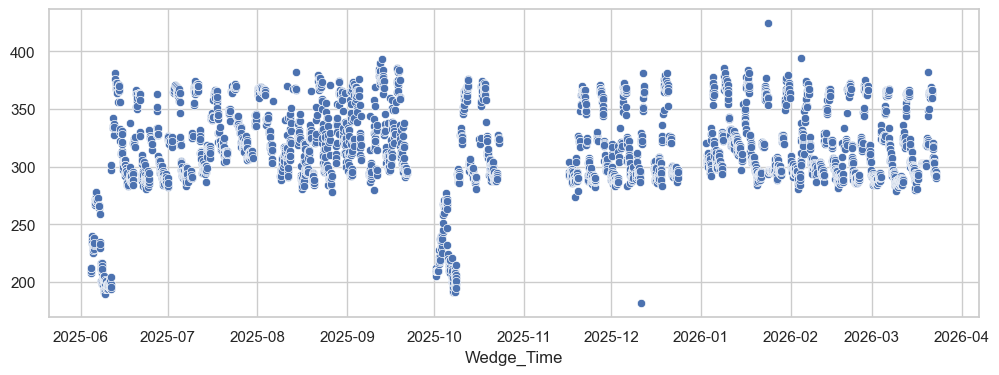

In [21]:
sns.scatterplot(x=turnup_data.Wedge_Time, y=electricity_model.predict(turnup_data[electricity_features()]))

In [24]:
electricity_model.predict(snapshot)

array([287.49390115])

In [18]:
electricity_model.predict(turnup_data[electricity_features()])

array([207.99265581, 209.22223229, 212.26092236, ..., 290.93147101,
       290.31146683, 291.90710567], shape=(3490,))

In [174]:
ypred = steam_model.predict(turnup_data[steam_features()])
ytrue = turnup_data["Steam__kWh/T_"]

In [175]:
ytrue

0       874.094116
1       890.995911
2       888.435242
3       892.674072
4       900.292603
           ...    
3485    907.835754
3486    932.088623
3487    905.283508
3488    954.989624
3489    956.610229
Name: Steam__kWh/T_, Length: 3490, dtype: float32

In [7]:
from utility import _summary_cost_plot

x_variable_summary = "week"
y_variable_summary = "Combined_cost__€/T_"
y_variable_summary_secondary = "Overprocessing_percentage"
color_variable_summary = "grade"

fig = _summary_cost_plot(process_data = process_data, 
                        x_variable_summary = x_variable_summary, 
                        y_variable_summary = y_variable_summary, 
                        y_variable_summary_secondary = y_variable_summary_secondary, 
                        color_variable_summary = color_variable_summary, 
                        type_summary = "bar", 
                        trim_summary = False, 
                        grades_summary = grades_summary, 
                        summary_bar_lines=True,
                        plotly_theme = plotly_theme)

_ = fig.update_layout(legend=dict(orientation="h",xanchor="right",x=0.5),                      
                      title=dict(text=f"Summary of {y_variable_summary} by {x_variable_summary}")
                      ),
fig.show()

In [11]:
descriptions = []

In [4]:
from utility import drilldown_df, _drilldown_analysis_plot, mix_effect, build_drilldown_text

for level in [1, 2, 3]:
    for object_drilldown in ["cost", "overprocessing"]:
        
        reference = "baseline"

        drilldown = drilldown_df(process_data[process_data.AB_Grade_ID.isin(grades_summary)], level , object_drilldown, reference)
        if level == 1 and object_drilldown=="cost":
            mix_contribution = mix_effect(object_drilldown, reference, grades_summary, process_data)
        else:
            mix_contribution = None

        descriptions_md = build_drilldown_text(drilldown.rename(columns={"cost":object_drilldown}), mix_contribution, lang=LANG)
        descriptions.append(descriptions_md)

        fig = _drilldown_analysis_plot(drilldown, mix_contribution,  level, object_drilldown, reference)
        fig = fig.update_layout(
                    title="",
                )
        fig.show()

In [31]:
target_range

(datetime.date(2026, 3, 9), datetime.date(2026, 3, 14))

In [32]:
baseline_range

(datetime.date(2026, 2, 8), datetime.date(2026, 3, 8))

In [33]:
turnup_data = _turnup_data(True, "", None, setpoint_df, steam_null)
process_data =  _process_data(turnup_data, target_range, baseline_range, steam_null)

In [6]:
target_range

(datetime.date(2026, 3, 9), datetime.date(2026, 3, 14))

In [42]:
process_data_clustered

,Current_basis_weight,Starch_uptake__g/m2_,Current_reel_moisture_average(reel),Fibre_cost__€/T_,AB_Grade_ID,target,cluster


In [40]:
import utility
importlib.reload(utility)

<module 'utility' from 'c:\\workspace\\costimiser\\utility.py'>

In [43]:
process_data_clustered = _process_data_clustered("", process_data, 'Steam__€/T_', "6010120", steam_features())

In [45]:
diagnostics = diagnostics[diagnostics.keep]
diagnostics["priority_score"] = (
    diagnostics["abs_contribution"]
    * diagnostics["delta_over_std"].fillna(0).clip(upper=1.0)
    * diagnostics["delta_over_range"].fillna(0).clip(upper=1.0)
)
diagnostics = diagnostics.sort_values("priority_score", ascending=False)

In [56]:
diagnostics

,variable,value_row1,value_row2,delta,abs_delta,std,p05,p95,delta_over_std,delta_over_range,contribution,abs_contribution,keep,priority_score
12,Fixative_2_mass_flow__g/T_,117.378227,324.804718,207.426491,207.426491,165.279083,105.429207,564.497906,1.255008,0.451842,-17.376725,17.376725,True,7.851533
23,DG4_Temperature_Inlet_Air,110.084564,103.343231,-6.741333,6.741333,7.419146,100.086792,117.818120,0.908640,0.380193,-16.089945,16.089945,True,5.558415
22,Jet/wire_ratio,-22.269285,-17.080072,5.189213,5.189213,6.421277,-35.963835,-15.290002,0.808128,0.251004,6.440110,6.440110,True,1.306333
10,Vacuum_uhle-box_bottom_felt,-0.362662,-0.377581,-0.014919,0.014919,0.044661,-0.411224,-0.261159,0.334043,0.099414,-6.835950,6.835950,True,0.227013
3,Starch_uptake_by_paper_Top_Roll__g/m2_,2.097613,2.212431,0.114818,0.114818,0.351692,1.387766,2.338685,0.326472,0.120744,3.403207,3.403207,True,0.134153
17,retention,0.796136,0.781072,-0.015064,0.015064,0.033377,0.745621,0.852301,0.451333,0.141206,1.773953,1.773953,True,0.113056
18,Dissolved_gas_before_dilution_water_deculator,1.723753,1.826188,0.102435,0.102435,0.382312,0.638889,1.844907,0.267934,0.084936,-3.947821,3.947821,True,0.089842
6,PD2_Fabric_tension,3.926013,3.890312,-0.035701,0.035701,0.103089,3.759083,4.100000,0.346313,0.104721,-2.286180,2.286180,True,0.082911
2,Steam_temperature_for_PM,167.310760,168.073639,0.762878,0.762878,2.864082,160.242822,168.751516,0.266361,0.089659,-3.177253,3.177253,True,0.075878
1,concentration_starch_working_tank_2,0.591228,0.604677,0.013449,0.013449,0.036419,0.495650,0.611071,0.369282,0.116521,-1.435687,1.435687,True,0.061777


In [60]:
diagnostics = diagnostics[diagnostics.keep]
diagnostics["priority_score"] = (
    diagnostics["abs_contribution"]
    * diagnostics["delta_over_std"].fillna(0).clip(upper=1.0)
    * diagnostics["delta_over_range"].fillna(0).clip(upper=1.0)
)
diagnostics = diagnostics.sort_values("priority_score", ascending=False)
shapley_contrib.merge(diagnostics, on="variable").sort_values("priority_score", ascending=False)

,AB_Grade_ID,variable,contribution_x,value_change,value_row1,value_row2,delta,abs_delta,std,p05,p95,delta_over_std,delta_over_range,contribution_y,abs_contribution,keep,priority_score
6,6010120,Fixative_2_mass_flow__g/T_,-0.437650,207.426483,117.378227,324.804718,207.426491,207.426491,165.279083,105.429207,564.497906,1.255008,0.451842,-17.376725,17.376725,True,7.851533
10,6010120,DG4_Temperature_Inlet_Air,-0.405241,-6.741333,110.084564,103.343231,-6.741333,6.741333,7.419146,100.086792,117.818120,0.908640,0.380193,-16.089945,16.089945,True,5.558415
9,6010120,Jet/wire_ratio,0.162200,5.189213,-22.269285,-17.080072,5.189213,5.189213,6.421277,-35.963835,-15.290002,0.808128,0.251004,6.440110,6.440110,True,1.306333
5,6010120,Vacuum_uhle-box_bottom_felt,-0.172170,-0.014919,-0.362662,-0.377581,-0.014919,0.014919,0.044661,-0.411224,-0.261159,0.334043,0.099414,-6.835950,6.835950,True,0.227013
2,6010120,Starch_uptake_by_paper_Top_Roll__g/m2_,0.085713,0.114818,2.097613,2.212431,0.114818,0.114818,0.351692,1.387766,2.338685,0.326472,0.120744,3.403207,3.403207,True,0.134153
7,6010120,retention,0.044679,-0.015064,0.796136,0.781072,-0.015064,0.015064,0.033377,0.745621,0.852301,0.451333,0.141206,1.773953,1.773953,True,0.113056
8,6010120,Dissolved_gas_before_dilution_water_deculator,-0.099430,0.102435,1.723753,1.826188,0.102435,0.102435,0.382312,0.638889,1.844907,0.267934,0.084936,-3.947821,3.947821,True,0.089842
3,6010120,PD2_Fabric_tension,-0.057580,-0.035701,3.926013,3.890312,-0.035701,0.035701,0.103089,3.759083,4.100000,0.346313,0.104721,-2.286180,2.286180,True,0.082911
1,6010120,Steam_temperature_for_PM,-0.080022,0.762878,167.310760,168.073639,0.762878,0.762878,2.864082,160.242822,168.751516,0.266361,0.089659,-3.177253,3.177253,True,0.075878
0,6010120,concentration_starch_working_tank_2,-0.036159,0.013449,0.591228,0.604677,0.013449,0.013449,0.036419,0.495650,0.611071,0.369282,0.116521,-1.435687,1.435687,True,0.061777


In [38]:
from utility import _process_data_clustered, _process_data_clustered_summary, _shapley_contrib_filtered, _working_plot, _cost_driver_plot, build_shapley_text, _working_plot

for grade_drilldown in ["6010120"]:
    for cost_component_drilldown in ['Steam__€/T_']:
        
        if cost_component_drilldown == 'Fibre_cost__€/T_':
            cost_component_features = fibre_features()
        elif cost_component_drilldown == 'Steam__€/T_':
            cost_component_features = steam_features()
        elif cost_component_drilldown == 'Electricity__€/T_':
            cost_component_features = electricity_features()
        elif cost_component_drilldown == 'Starch__€/T_':
            cost_component_features = starch_features()

        process_data_clustered = _process_data_clustered("", process_data, cost_component_drilldown, grade_drilldown, cost_component_features)
        if len(process_data_clustered)>0 and "current" in process_data_clustered.target.unique() and "historic" in process_data_clustered.target.unique():
            df1, df2 = _process_data_clustered_summary(process_data_clustered, cost_component_drilldown, grade_drilldown, fibre_cost, steam_cost, electricity_cost, starch_cost, steam_features, electricity_features, starch_features, fibre_features)

            shapley_contrib, contrib_full, diagnostics = _shapley_contrib_filtered("", turnup_data, df1, df2, cost_component_drilldown, grade_drilldown, fibre_cost, steam_cost, electricity_cost, starch_cost, steam_features, electricity_features, starch_features, fibre_features)

            shapley_md = build_shapley_text(shapley_contrib, top_frac=0.20, lang=LANG)
            descriptions.append(shapley_md)

            fig = _cost_driver_plot(shapley_contrib)
            fig.show()

            fig = _working_plot(shapley_contrib, df1, df2, cost_component_drilldown)
            fig.show()

['Moisture_out_of_PreDryer', 'concentration_starch_working_tank_2', 'Steam_temperature_for_PM', 'Starch_uptake_by_paper_Top_Roll__g/m2_', 'Vacuum_wire_suction_box_2', 'Current_basis_weight', 'PD2_Fabric_tension', 'Cylinder_38_differential_pressure', 'Vacuum_wet_suction_box', 'Current_reel_width', 'Vacuum_uhle-box_bottom_felt', 'Top_wire_tenstion', 'Fixative_2_mass_flow__g/T_', 'concentration_starch_working_tank_1', 'Starch_uptake_by_paper_Bottom_Roll__g/m2_', 'Linepressure_1st_press_DS__bar_', 'Storage_tank_temperature', 'retention', 'Dissolved_gas_before_dilution_water_deculator', 'Linepressure_shoe_press__bar_', 'Total_Dewatering_Press', 'Speed_PD1', 'Jet/wire_ratio', 'DG4_Temperature_Inlet_Air']
['Moisture_out_of_PreDryer', 'concentration_starch_working_tank_2', 'Steam_temperature_for_PM', 'Starch_uptake_by_paper_Top_Roll__g/m2_', 'Vacuum_wire_suction_box_2', 'Current_basis_weight', 'PD2_Fabric_tension', 'Cylinder_38_differential_pressure', 'Vacuum_wet_suction_box', 'Current_reel_wi

In [3]:
diagnostics

,variable,value_row1,value_row2,delta,abs_delta,std,p05,p95,delta_over_std,delta_over_range,contribution,abs_contribution,keep
12,Fixative_2_mass_flow__g/T_,117.378227,324.804718,207.426491,207.426491,165.279083,105.429207,564.497906,1.255008e+00,4.518419e-01,-17.376725,17.376725,True
23,DG4_Temperature_Inlet_Air,110.084564,103.343231,-6.741333,6.741333,7.419146,100.086792,117.818120,9.086401e-01,3.801933e-01,-16.089945,16.089945,True
10,Vacuum_uhle-box_bottom_felt,-0.362662,-0.377581,-0.014919,0.014919,0.044661,-0.411224,-0.261159,3.340435e-01,9.941426e-02,-6.835950,6.835950,True
22,Jet/wire_ratio,-22.269285,-17.080072,5.189213,5.189213,6.421277,-35.963835,-15.290002,8.081279e-01,2.510039e-01,6.440110,6.440110,True
7,Cylinder_38_differential_pressure,0.199470,0.195150,-0.004321,0.004321,0.021585,0.175258,0.215256,2.001670e-01,1.080218e-01,5.218011,5.218011,False
21,Speed_PD1,1246.340332,1229.617310,-16.723022,16.723022,83.421555,1028.099976,1322.065051,2.004640e-01,5.688779e-02,4.546144,4.546144,False
18,Dissolved_gas_before_dilution_water_deculator,1.723753,1.826188,0.102435,0.102435,0.382312,0.638889,1.844907,2.679342e-01,8.493614e-02,-3.947821,3.947821,True
4,Vacuum_wire_suction_box_2,-0.581372,-0.572509,0.008863,0.008863,0.046002,-0.629485,-0.511335,1.926744e-01,7.501828e-02,-3.486108,3.486108,False
3,Starch_uptake_by_paper_Top_Roll__g/m2_,2.097613,2.212431,0.114818,0.114818,0.351692,1.387766,2.338685,3.264723e-01,1.207441e-01,3.403360,3.403360,True
2,Steam_temperature_for_PM,167.310760,168.073639,0.762878,0.762878,2.864082,160.242822,168.751516,2.663605e-01,8.965870e-02,-3.177253,3.177253,True


In [8]:
shapley_contrib.keys()

Index(['AB_Grade_ID', 'variable', 'contribution', 'value_change'], dtype='object')

In [ ]:
from utility import _process_data_clustered, _process_data_clustered_summary, _shapley_contrib, _working_plot, _cost_driver_plot, build_shapley_text

for grade_drilldown in ["6010120"]:#["6010085", "3200115", "6010100", "6010120"]:
    for cost_component_drilldown in ['Steam__€/T_']:#['Fibre_cost__€/T_', 'Steam__€/T_', 'Electricity__€/T_', 'Starch__€/T_']:
        
        if cost_component_drilldown == 'Fibre_cost__€/T_':
            cost_component_features = fibre_features()
        elif cost_component_drilldown == 'Steam__€/T_':
            cost_component_features = steam_features()
        elif cost_component_drilldown == 'Electricity__€/T_':
            cost_component_features = electricity_features()
        elif cost_component_drilldown == 'Starch__€/T_':
            cost_component_features = starch_features()

        process_data_clustered = _process_data_clustered("", process_data, cost_component_drilldown, grade_drilldown, cost_component_features)
        if len(process_data_clustered)>0 and "current" in process_data_clustered.target.unique() and "historic" in process_data_clustered.target.unique():
            df1, df2 = _process_data_clustered_summary(process_data_clustered, cost_component_drilldown, grade_drilldown, fibre_cost, steam_cost, electricity_cost, starch_cost, steam_features, electricity_features, starch_features, fibre_features)

            shapley_contrib = _shapley_contrib("", df1, df2, cost_component_drilldown, grade_drilldown, fibre_cost, steam_cost, electricity_cost, starch_cost, steam_features, electricity_features, starch_features, fibre_features)

            shapley_md = build_shapley_text(shapley_contrib, top_frac=0.20, lang=LANG)
            descriptions.append(shapley_md)

            fig = _cost_driver_plot(shapley_contrib)
            fig.show()

In [50]:
shapley_contrib

,AB_Grade_ID,variable,contribution,value_change
0,6010085,Current_basis_weight,-0.033087,-0.082352
1,6010085,Starch_uptake__g/m2_,-1.106420,0.132245
2,6010085,Current_reel_moisture_average(reel),0.139507,-0.019793


# AI Process Analysis API

In [5]:
from datetime import datetime

target_from = "2026-03-09"
target_to = "2026-03-14"
baseline_from = "2026-02-08"
baseline_to = "2026-03-26"

if isinstance(target_from, str):
    target_from = datetime.strptime(target_from, "%Y-%m-%d").date()

if isinstance(target_to, str):
    target_to = datetime.strptime(target_to, "%Y-%m-%d").date()

if isinstance(baseline_from, str):
    baseline_from = datetime.strptime(baseline_from, "%Y-%m-%d").date()

if isinstance(baseline_to, str):
    baseline_to = datetime.strptime(baseline_to, "%Y-%m-%d").date()

process_data =  _process_data(turnup_data, (target_from,target_to), (baseline_from,baseline_to), steam_null=False)

NameError: name '_process_data' is not defined

In [25]:
import requests
 
url = "http://localhost:8000/shapley_contribution"
 
payload = {
    "target_from": "2026-03-09",
    "target_to": "2026-03-14",
    "baseline_from": "2026-02-08",
    "baseline_to": "2026-03-8",
    "grade": "6010120",
    "cost_component": "steam"
}
 
response = requests.post(url, json=payload)
 
# Check response
response.raise_for_status()
 
data = response.json()
 
print(data)

{'target_from': '2026-03-09', 'target_to': '2026-03-14', 'baseline_from': '2026-02-08', 'baseline_to': '2026-03-08', 'grade': '6010120', 'cost_component': 'steam', 'rows': [{'AB_Grade_ID': '6010120', 'variable': 'Moisture_out_of_PreDryer', 'contribution': -0.006036230859906495, 'value_change': -0.021042823791503906}, {'AB_Grade_ID': '6010120', 'variable': 'concentration_starch_working_tank_2', 'contribution': 0.026972852112671673, 'value_change': -0.005706071853637695}, {'AB_Grade_ID': '6010120', 'variable': 'Steam_temperature_for_PM', 'contribution': -0.8590090566558787, 'value_change': 4.2925262451171875}, {'AB_Grade_ID': '6010120', 'variable': 'Starch_uptake_by_paper_Top_Roll__g/m2_', 'contribution': 0.1698218529371522, 'value_change': 0.11623919010162354}, {'AB_Grade_ID': '6010120', 'variable': 'Vacuum_wire_suction_box_2', 'contribution': 0.15976461584895907, 'value_change': -0.008453786373138428}, {'AB_Grade_ID': '6010120', 'variable': 'Current_basis_weight', 'contribution': -0.01